# **DATA MODELING AND MODEL EVALUATION**

---

## **1. Import Libraries**

In [61]:
import pandas as pd
import numpy as np
import sys
from scipy import stats
from utils import (
    sigmoid, make_sigmoid_basis, fit_ridge_closed_form, predict, metrics,
    mse, fit_ridge, fit_lasso_cd, add_bias, poly_features, rbf_features, sigmoid_stable,
    sigmoid_features, spline_features, make_design_matrix, select_feature_groups,
    interaction_terms, time_series_cv_indices, fit_elastic_net_cd, forward_selection, 
    backward_elimination, fit_ols, compute_residuals, breusch_pagan_test, estimate_weights_from_residuals, fit_wls,
    fit_ols_minibatch_gd, step_decay_schedule, cosine_annealing_schedule
)
import matplotlib.pyplot as plt
import time

## **2. Load Data**

In [62]:
data_dir = '../../data/processed/'

train_df = pd.read_csv(data_dir + 'Energy_Use_train.csv')
val_df = pd.read_csv(data_dir + 'Energy_Use_val.csv')
test_df = pd.read_csv(data_dir + 'Energy_Use_test.csv')

target_col = 'Appliances'

# Tách X và y
y_train_raw = train_df[target_col]
X_train_raw = train_df.drop(columns=[target_col])

y_val_raw = val_df[target_col]
X_val_raw = val_df.drop(columns=[target_col])

y_test_raw = test_df[target_col]
X_test_raw = test_df.drop(columns=[target_col])

# Chuyển đổi format và thêm bias
y_train = y_train_raw.values
y_val = y_val_raw.values
y_test = y_test_raw.values

# Thêm cột toàn số 1 (Bias) vào đầu ma trận đặc trưng X để tạo ma trận Phi
Phi_train = add_bias(X_train_raw.values)
Phi_val = add_bias(X_val_raw.values)
Phi_test = add_bias(X_test_raw.values)

# Lấy danh sách tên đặc trưng để in kết quả (Cột 0 là Bias)
feature_names = ['Bias (w0)'] + list(X_train_raw.columns)

print(f"Tập Train      : Phi = {Phi_train.shape}, y = {y_train.shape}")
print(f"Tập Validation : Phi = {Phi_val.shape}, y = {y_val.shape}")
print(f"Tập Test       : Phi = {Phi_test.shape}, y = {y_test.shape}")

Tập Train      : Phi = (13813, 40), y = (13813,)
Tập Validation : Phi = (2961, 40), y = (2961,)
Tập Test       : Phi = (2961, 40), y = (2961,)


## **3. Tìm kiếm tham số tối ưu cho Ridge (L2) và Lasso (L1)**

Trong phần này, chúng ta sẽ tìm kiếm hệ số phạt $\lambda$ tối ưu cho hai mô hình:
* **Ridge Regression (L2 Penalty):** Phạt bình phương các trọng số. Giúp giải quyết hiện tượng đa cộng tuyến và giảm Overfitting.
* **Lasso Regression (L1 Penalty):** Phạt trị tuyệt đối các trọng số. Giúp tạo ra các nghiệm thưa, ép các trọng số không quan trọng về đúng $0$.

**Chiến lược tối ưu hóa:**
1. **Grid Search:** Tạo một lưới gồm 50 giá trị $\lambda$ trải dài từ $10^3$ đến $10^{-4}$ trên thang đo logarit.
2. **Time Series K-Fold Cross Validation (k=10):** Do dữ liệu mang tính chất chuỗi thời gian, việc xáo trộn ngẫu nhiên trong K-Fold truyền thống sẽ dẫn đến lỗi **rò rỉ dữ liệu** - dùng tương lai để dự đoán quá khứ. 
   * Giải pháp: Cài đặt kỹ thuật **Expanding Window (Forward Chaining)**. Tập Train sẽ mở rộng dần theo thời gian và tập Validation luôn nối tiếp ngay sau đó.
3. **Kỹ thuật Warm Start cho Lasso:**
   * Lasso được giải bằng thuật toán **Coordinate Descent**. 
   * Để tăng tốc độ hội tụ khi duyệt qua lưới $\lambda$, ta bắt buộc duyệt $\lambda$ theo thứ tự **giảm dần**. Tại mỗi bước, trọng số $w$ tối ưu của vòng lặp trước sẽ được truyền vào làm điểm khởi tạo ($w_{init}$) cho vòng lặp hiện tại. Nhờ có sẵn từ trước, thuật toán hội tụ cực nhanh chỉ sau vài vòng lặp.

In [3]:
# 1. Thiết lập Grid Search và Folds
lam_grid = np.logspace(3, -4, 50)
k_folds = 10
folds = time_series_cv_indices(len(Phi_train), k=k_folds)

ridge_cv_mses = []
lasso_cv_mses = []
w_inits_lasso = [None] * k_folds # Khởi tạo Warm Start cho 10 folds

print(f"Đang chạy {k_folds}-Fold CV (Grid Search + Warm Start)...")

# 2. Vòng lặp tối ưu
for idx, lam in enumerate(lam_grid):
    # In ra tiến độ hiện tại, end='\r' giúp ghi đè lên dòng cũ
    print(f" Đang xử lý Lambda thứ {idx + 1}/{len(lam_grid)} (log10(λ) = {np.log10(lam):.2f})...", end='\r')
    
    mse_r_folds, mse_l_folds = [], []
    
    for i, (train_idx, val_idx) in enumerate(folds):
        Phi_tr, y_tr = Phi_train[train_idx], y_train[train_idx]
        Phi_va, y_va = Phi_train[val_idx], y_train[val_idx]
        
        # Mô hình Ridge
        w_r = fit_ridge(Phi_tr, y_tr, lam, bias_is_first=True)
        mse_r_folds.append(mse(y_va, Phi_va @ w_r))
        
        # Mô hình Lasso (Áp dụng Warm Start)
        w_l = fit_lasso_cd(Phi_tr, y_tr, lam, num_iters=500, bias_is_first=True, w_init=w_inits_lasso[i])
        w_inits_lasso[i] = w_l.copy() # Cập nhật điểm xuất phát cho vòng tiếp theo
        mse_l_folds.append(mse(y_va, Phi_va @ w_l))
        
    ridge_cv_mses.append(np.mean(mse_r_folds))
    lasso_cv_mses.append(np.mean(mse_l_folds))

# In ra dấu hoàn thành đè lên dòng đang xử lý
print("Đã xử lý xong toàn bộ 50 giá trị Lambda!                            ")

# 3. Lựa chọn Lambda tối ưu
best_lam_ridge = lam_grid[np.argmin(ridge_cv_mses)]
best_lam_lasso = lam_grid[np.argmin(lasso_cv_mses)]

print("\n=> Ridge Lambda tối ưu : {:.5f} (log10 = {:.2f})".format(best_lam_ridge, np.log10(best_lam_ridge)))
print("=> Lasso Lambda tối ưu : {:.5f} (log10 = {:.2f})".format(best_lam_lasso, np.log10(best_lam_lasso)))

Đang chạy 10-Fold CV (Grid Search + Warm Start)...
Đã xử lý xong toàn bộ 50 giá trị Lambda!                            

=> Ridge Lambda tối ưu : 719.68567 (log10 = 2.86)
=> Lasso Lambda tối ưu : 1000.00000 (log10 = 3.00)


## **4. Trực quan hóa đường Regularization**

**Khái niệm:** Regularization Path là đồ thị biểu diễn sự thay đổi của các hệ số trọng số $w$ khi ta thay đổi độ lớn của lực phạt $\log_{10}(\lambda)$. 

**Phương pháp:** Ta sẽ huấn luyện lại Ridge và Lasso trên **toàn bộ tập Train** với danh sách 50 giá trị $\lambda$ đã có. Đồ thị sẽ bỏ qua hệ số $w_0$ (Bias) vì theo nguyên tắc toán học, hệ số tự do không bị áp dụng hình phạt Regularization để không làm sai lệch giá trị trung bình của dự đoán. 

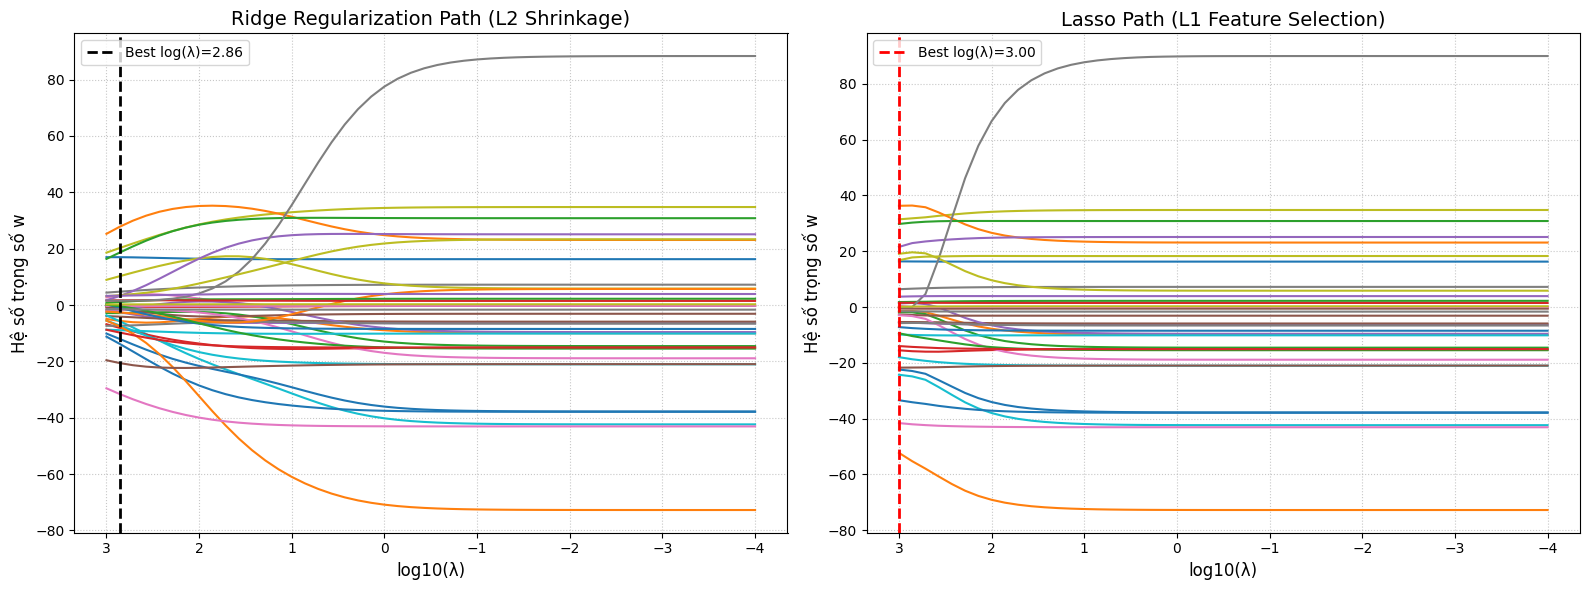

In [12]:
ridge_paths, lasso_paths = [], []
w_init_full_lasso = None

# Huấn luyện trên toàn bộ tập Train
for lam in lam_grid:
    w_r_full = fit_ridge(Phi_train, y_train, lam, bias_is_first=True)
    ridge_paths.append(w_r_full)
    
    w_l_full = fit_lasso_cd(Phi_train, y_train, lam, num_iters=1000, bias_is_first=True, w_init=w_init_full_lasso)
    w_init_full_lasso = w_l_full.copy()
    lasso_paths.append(w_l_full)

ridge_paths, lasso_paths = np.array(ridge_paths), np.array(lasso_paths)

# Vẽ đồ thị
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Đồ thị Ridge
axes[0].plot(np.log10(lam_grid), ridge_paths[:, 1:]) 
axes[0].axvline(np.log10(best_lam_ridge), color='black', linestyle='--', linewidth=2, label=f'Best log(λ)={np.log10(best_lam_ridge):.2f}')
axes[0].invert_xaxis()
axes[0].set_title('Ridge Regularization Path (L2 Shrinkage)', fontsize=14)
axes[0].set_xlabel('log10(λ)', fontsize=12)
axes[0].set_ylabel('Hệ số trọng số w', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=0.7)
axes[0].legend()

# Đồ thị Lasso
axes[1].plot(np.log10(lam_grid), lasso_paths[:, 1:]) 
axes[1].axvline(np.log10(best_lam_lasso), color='red', linestyle='--', linewidth=2, label=f'Best log(λ)={np.log10(best_lam_lasso):.2f}')
axes[1].invert_xaxis()
axes[1].set_title('Lasso Path (L1 Feature Selection)', fontsize=14)
axes[1].set_xlabel('log10(λ)', fontsize=12)
axes[1].set_ylabel('Hệ số trọng số w', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
# Lấy bộ trọng số tại mức phạt cực đại (Lambda lớn nhất nằm ở index 0 của mảng lam_grid)
w_ridge_max = ridge_paths[0][1:] # Bỏ qua cột Bias ở vị trí 0
w_lasso_max = lasso_paths[0][1:]

print("Kiểm tra mức độ trả về 0 của lambda lớn nhất")

# Định nghĩa một ngưỡng cực kỳ nhỏ, gần như bằng 0
epsilon = 1e-10

# Lấy danh sách tên đặc trưng 
feats_no_bias = feature_names[1:]

# Tìm index của các hệ số bị triệt tiêu (< epsilon)
ridge_zero_idx = np.where(np.abs(w_ridge_max) < epsilon)[0]
lasso_zero_idx = np.where(np.abs(w_lasso_max) < epsilon)[0]

# 1. RIDGE
print(f"1. RIDGE: Số lượng hệ số bị triệt tiêu hoàn toàn: {len(ridge_zero_idx)} / {len(w_ridge_max)}")
if len(ridge_zero_idx) > 0:
    for idx in ridge_zero_idx:
        print(f"   - Cột '{feats_no_bias[idx]}': Trọng số = {w_ridge_max[idx]}")
else:
    print("   -> Ridge không triệt tiêu bất kỳ đặc trưng nào (chỉ làm nhỏ đi chứ không bằng 0).")

# 2. LASSO
print(f"\n2. LASSO: Số lượng hệ số bị triệt tiêu hoàn toàn: {len(lasso_zero_idx)} / {len(w_lasso_max)}")
if len(lasso_zero_idx) > 0:
    print("   Danh sách các đặc trưng bị Lasso đẩy về 0:")
    for idx in lasso_zero_idx:
        # In ra dưới dạng số thực để thấy rõ nó là 0.0 hoặc con số cực kỳ tiệm cận 0
        print(f"   - Cột '{feats_no_bias[idx]}': Trọng số = {w_lasso_max[idx]}")

Kiểm tra mức độ trả về 0 của lambda lớn nhất
1. RIDGE: Số lượng hệ số bị triệt tiêu hoàn toàn: 0 / 39
   -> Ridge không triệt tiêu bất kỳ đặc trưng nào (chỉ làm nhỏ đi chứ không bằng 0).

2. LASSO: Số lượng hệ số bị triệt tiêu hoàn toàn: 3 / 39
   Danh sách các đặc trưng bị Lasso đẩy về 0:
   - Cột 'T_out': Trọng số = 0.0
   - Cột 'rv2': Trọng số = -1.2971147198238387e-14
   - Cột 'T_indoor_avg': Trọng số = 0.0


**Phân tích Regularization Path:**

Đọc đồ thị từ Trái sang Phải (tương ứng với lực phạt $\lambda$ giảm dần):

* **Ridge Path:** Ta thấy sự thu nhỏ diễn ra rất mượt mà. Ở $\lambda$ lớn, các hệ số hội tụ về gần $0$ nhưng **không bao giờ bằng $0$ tuyệt đối**. Điều này minh chứng cho việc Ridge phân bổ đều trọng số để chống đa cộng tuyến, nhưng không loại bỏ hoàn toàn bất kỳ đặc trưng nào.
* **Lasso Path:** Thể hiện rõ bản chất **Feature Selection**. Khi lực phạt mạnh, tất cả các hệ số bị ép chặt về mức $0$. Khi $\lambda$ được nới lỏng, các đường màu sắc (đại diện cho các đặc trưng) bắt đầu bứt phá khỏi vạch $0$. Những đường bứt lên sớm nhất và duy trì độ lớn ổn định chính là những tín hiệu dự đoán cốt lõi nhất của bộ dữ liệu. Đường đứt nét màu đỏ xác định tọa độ $\lambda$ cân bằng nhất giữa độ phức tạp và sai số mô hình.

## **5. Cài đặt Elastic Net và Phân tích vùng tối ưu**

**Lý thuyết:** Mặc dù Lasso rất mạnh trong việc lọc đặc trưng, nó có một điểm yếu: Khi đối mặt với một nhóm các biến có tương quan cao (Ví dụ: Nhiệt độ phòng $T_1$ và $T_2$), Lasso thường có xu hướng chỉ chọn ngẫu nhiên một biến và ép biến còn lại về $0$.

**Elastic Net** ra đời để khắc phục điều này bằng cách lai tạo cả hai hình phạt. Hàm mất mát được định nghĩa như sau:
$$E(w) = \frac{1}{2} \|t - \Phi w\|^2 + \lambda_1 \|w\|_1 + \frac{\lambda_2}{2} \|w\|^2$$

**Phương pháp phân tích:**
Để tìm ra tỷ lệ vàng giữa $\lambda_1$ và $\lambda_2$, ta thiết lập một **Grid Search 2 chiều**. Với mỗi tổ hợp $(\lambda_1, \lambda_2)$, ta chạy Time Series CV để đo lường sai số MSE. Kết quả sẽ được trực quan hóa bằng một bản đồ nhiệt Contour Plot để xác định vùng trũng của lỗi.

Đang quét lưới 2D tìm vùng tối ưu cho Elastic Net...
=> Tổ hợp tối ưu: log10(L1) = 3.4545 | log10(L2) = 2.9091
   (Tương đương giá trị thực: L1 = 2848.0359, L2 = 811.1308)


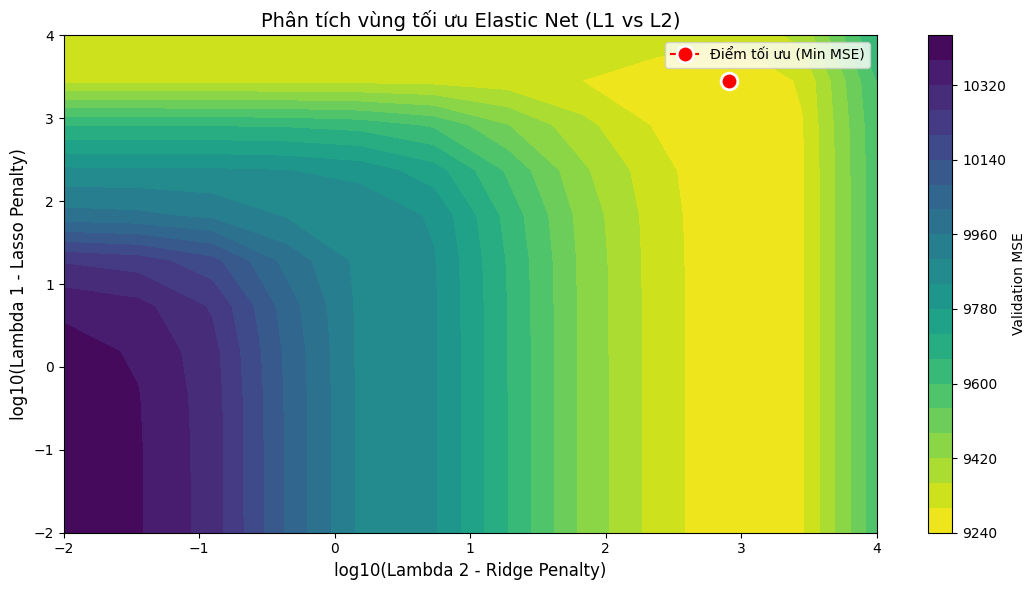

In [21]:
l1_vals = np.logspace(-2, 4, 12) 
l2_vals = np.logspace(-2, 4, 12) 
mse_matrix = np.zeros((len(l1_vals), len(l2_vals)))

# Dùng 5-fold để tối ưu thời gian chạy Grid 2D
folds_enet = time_series_cv_indices(len(Phi_train), k=5) 

best_mse = float('inf')
best_l1, best_l2 = 0, 0

print("Đang quét lưới 2D tìm vùng tối ưu cho Elastic Net...")
for i, l1 in enumerate(l1_vals):
    for j, l2 in enumerate(l2_vals):
        fold_mses = []
        for train_idx, val_idx in folds_enet:
            Phi_tr, y_tr = Phi_train[train_idx], y_train[train_idx]
            Phi_va, y_va = Phi_train[val_idx], y_train[val_idx]
            
            w_enet = fit_elastic_net_cd(Phi_tr, y_tr, lam1=l1, lam2=l2, num_iters=500, bias_is_first=True)
            y_pred = Phi_va @ w_enet
            fold_mses.append(mse(y_va, y_pred))
            
        avg_mse = np.mean(fold_mses)
        mse_matrix[i, j] = avg_mse
        if avg_mse < best_mse:
            best_mse, best_l1, best_l2 = avg_mse, l1, l2

# In kết quả theo dạng log10
print(f"=> Tổ hợp tối ưu: log10(L1) = {np.log10(best_l1):.4f} | log10(L2) = {np.log10(best_l2):.4f}")
print(f"   (Tương đương giá trị thực: L1 = {best_l1:.4f}, L2 = {best_l2:.4f})")

# Vẽ Contour Plot
plt.figure(figsize=(11, 6))
X, Y = np.meshgrid(np.log10(l2_vals), np.log10(l1_vals))
cp = plt.contourf(X, Y, mse_matrix, levels=20, cmap='viridis_r')
plt.colorbar(cp, label='Validation MSE')

plt.plot(np.log10(best_l2), np.log10(best_l1), marker='o', color='red', 
         markeredgecolor='white', markersize=12, markeredgewidth=2, 
         label='Điểm tối ưu (Min MSE)')

plt.title('Phân tích vùng tối ưu Elastic Net (L1 vs L2)', fontsize=14)
plt.xlabel('log10(Lambda 2 - Ridge Penalty)', fontsize=12)
plt.ylabel('log10(Lambda 1 - Lasso Penalty)', fontsize=12)

plt.xlim(-2, 4)
plt.ylim(-2, 4)
plt.legend()
plt.tight_layout()
plt.show()

**Phân tích đồ thị Contour:**
* Vùng màu sáng (vàng/xanh nhạt) trên biểu đồ đại diện cho khu vực tối ưu của cả 2 tham số `lambda 1` và `lambda 2`, ở vùng này mô hình có sai số trên tập Validation thấp nhất.
* Vị trí của điểm tối ưud cho ta biết bộ dữ liệu này ưu tiên hình phạt nào hơn. Sự kết hợp thành công này giúp mô hình vừa có khả năng loại bỏ nhiễu của L1, vừa duy trì được sự ổn định nhóm của L2.

## **6. Lựa chọn đặc trưng**

**Mục tiêu:** Trong bộ dữ liệu thực tế, việc giữ lại quá nhiều cột không chỉ làm tăng chi phí tính toán mà còn gây ra Overfitting. Ta sẽ so sánh 3 phương pháp độc lập để tìm ra nhóm đặc trưng (khoảng 15 cột) có sức mạnh dự đoán năng lượng tốt nhất.

1. **Forward Stepwise Selection:** Xuất phát từ mô hình chỉ có Bias. Trải qua từng vòng lặp, thuật toán thử ghép thêm từng đặc trưng còn lại vào mô hình, tính lỗi trên tập Validation, và chọn ra đặc trưng duy nhất làm giảm lỗi mạnh nhất để kết nạp.
2. **Backward Elimination:** Xuất phát từ mô hình chứa toàn bộ đặc trưng. Mỗi bước, thuật toán thử rút lõi từng đặc trưng ra. Đặc trưng nào bị rút ra mà ít làm tăng lỗi nhất (hoặc làm lỗi giảm đi) sẽ bị coi là rác và bị loại bỏ vĩnh viễn.
3. **Lasso:** Không cần vòng lặp bên ngoài. Lasso tự động ép các hệ số không quan trọng về $0$ ngay trong quá trình giải bài toán tối ưu. Ta chỉ cần lọc các trọng số $w \neq 0$.

In [32]:
target_k = 32

print("1. Forward Stepwise Selection")
fw_idx = forward_selection(Phi_train, y_train, Phi_val, y_val, k_features=target_k, lam=best_lam_ridge)
fw_feats = [feature_names[i] for i in fw_idx if i != 0]
print(f"Danh sách {len(fw_feats)} cột được chọn:\n{fw_feats}\n")

print("2. Backward Elimination")
bw_idx = backward_elimination(Phi_train, y_train, Phi_val, y_val, target_features=target_k, lam=best_lam_ridge)
bw_feats = [feature_names[i] for i in bw_idx if i != 0]
print(f"Danh sách {len(bw_feats)} cột được giữ lại:\n{bw_feats}\n")

print("3. Lasso Nonzero Coefficients")
# Huấn luyện Lasso với lambda tốt nhất trên toàn bộ tập Train
w_lasso_best = fit_lasso_cd(Phi_train, y_train, best_lam_lasso, num_iters=1000, bias_is_first=True)
lasso_idx = [i for i, w in enumerate(w_lasso_best) if abs(w) > 1e-5]
lasso_feats = [feature_names[i] for i in lasso_idx if i != 0]
print(f"Lasso giữ lại {len(lasso_feats)} cột:\n{lasso_feats}\n")

# Phân tích sự giao thoa giữa 3 phương pháp
common_feats = set(fw_feats) & set(bw_feats) & set(lasso_feats)
print(f"Các đặc trưng xuất hiện ở cả 3 cách ({len(common_feats)}):")
for feat in common_feats:
    print(f"  - {feat}")

1. Forward Stepwise Selection
Danh sách 32 cột được chọn:
['Hour_cos', 'Hour_sin', 'RH_1', 'Is_Business_Hour', 'T3', 'Month_cos', 'T2', 'T7', 'RH_8', 'RH_3', 'T9', 'T_indoor_avg', 'Press_mm_hg', 'Minute_sin', 'DayOfWeek_sin', 'Is_Weekend', 'T4', 'Month_sin', 'Minute_cos', 'rv1', 'rv2', 'RH_5', 'Windspeed', 'T5', 'T1', 'RH_2', 'lights', 'T8', 'RH_7', 'Visibility', 'RH_6', 'Tdewpoint']

2. Backward Elimination
Danh sách 31 cột được giữ lại:
['lights', 'T4', 'RH_5', 'RH_out', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'RH_4', 'T6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'T_out', 'Press_mm_hg', 'Tdewpoint', 'rv1', 'rv2', 'T_indoor_avg', 'Temp_Diff', 'Is_Weekend', 'Is_Business_Hour', 'Month_cos', 'DayOfWeek_sin', 'Hour_sin', 'Hour_cos', 'Minute_sin', 'Minute_cos']

3. Lasso Nonzero Coefficients
Lasso giữ lại 36 cột:
['lights', 'T1', 'T4', 'RH_5', 'RH_6', 'RH_9', 'RH_out', 'Windspeed', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'RH_4', 'T5', 'T6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'Press_mm_hg', 'Visibility', 

**Phân tích kết quả lựa chọn đặc trưng:**
* **Về hiệu năng thuật toán:** 
  - Forward và Backward là các phương pháp Gói (Wrapper Methods). Chúng tốn rất nhiều tài nguyên tính toán vì độ phức tạp lên tới $\mathcal{O}(p^2)$ bước lặp, mỗi bước phải giải lại một bài toán hồi quy.
  - Ngược lại, Lasso là phương pháp Nhúng (Embedded Method), cực kì nhanh và ít bị overfitting.
* **Về mức độ giao thoa:** - Những đặc trưng nằm trong danh sách **giao thoa cốt lõi** của cả 3 phương pháp là những biến số có ý nghĩa vật lý/thống kê cực kỳ cao đối với năng lượng tiêu thụ (Ví dụ như Nhiệt độ ngoài trời, Giờ trong ngày). Việc loại bỏ các biến nhiễu giúp mô hình tăng cường khả năng tổng quát hóa khi áp dụng vào thực tế.

## **7. Tổng kết và đánh giá mô hình**

In [34]:
# Lọc ma trận đặc trưng các cột giao thao
# Thêm 0 vào đầu mảng để giữ lại cột Bias (Hệ số tự do)
selected_indices = [0] + [feature_names.index(feat) for feat in common_feats]

# Lọc ma trận Phi_train và Phi_test chỉ giữ lại các cột đã chọn
Phi_train_sel = Phi_train[:, selected_indices]
Phi_test_sel = Phi_test[:, selected_indices]

print(f"Đang huấn luyện các mô hình trên {len(common_feats)} đặc trưng cốt lõi...")


w_ridge_final = fit_ridge(Phi_train_sel, y_train, lam=best_lam_ridge, bias_is_first=True)
w_lasso_final = fit_lasso_cd(Phi_train_sel, y_train, lam=best_lam_lasso, num_iters=1000, bias_is_first=True)
w_enet_final = fit_elastic_net_cd(Phi_train_sel, y_train, lam1=best_l1, lam2=best_l2, num_iters=1000, bias_is_first=True)


print("\nKết quả đánh giá trên tập Test")
print(f"1. Ridge Regression MSE       : {mse(y_test, Phi_test_sel @ w_ridge_final):.4f}")
print(f"2. Lasso Regression MSE       : {mse(y_test, Phi_test_sel @ w_lasso_final):.4f}")
print(f"3. Elastic Net Regression MSE : {mse(y_test, Phi_test_sel @ w_enet_final):.4f}")

Đang huấn luyện các mô hình trên 24 đặc trưng cốt lõi...

Kết quả đánh giá trên tập Test
1. Ridge Regression MSE       : 6965.2590
2. Lasso Regression MSE       : 6943.5375
3. Elastic Net Regression MSE : 6990.4466


# **Phúc**

## **2. Load Data for Model**

In [8]:

energy_path = "../../data/raw/Energy_Use.csv"
df_energy = pd.read_csv(energy_path)
if 'date' in df_energy.columns:
    df_energy['date'] = pd.to_datetime(df_energy['date'], format='%d-%m-%Y %H:%M', errors='ignore')


C:\Users\Admin\AppData\Local\Temp\ipykernel_14584\2949817478.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df_energy['date'] = pd.to_datetime(df_energy['date'], format='%d-%m-%Y %H:%M', errors='ignore')


In [9]:

# --- 9.2 Time-series split (no shuffle) ---
# Target: Appliances
# Features: all numeric except target; drop raw datetime column

df_model = df_energy.copy()
if 'date' in df_model.columns:
    df_model = df_model.sort_values('date').reset_index(drop=True)

if 'Appliances' not in df_model.columns:
    raise ValueError("Column 'Appliances' not found in df_energy")

y = df_model['Appliances'].to_numpy(dtype=float)

X_df = df_model.drop(columns=['Appliances'], errors='ignore')
X_df = X_df.drop(columns=['date'], errors='ignore')

# Keep only numeric columns
X_df = X_df.select_dtypes(include=[np.number]).copy()
feature_names = list(X_df.columns)
X = X_df.to_numpy(dtype=float)

n = X.shape[0]
train_end = int(0.70 * n)
val_end = int(0.80 * n)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

print("Shapes:")
print("- X_train:", X_train.shape, "y_train:", y_train.shape)
print("- X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("- X_test :", X_test.shape, "y_test :", y_test.shape)

# --- 9.3 Feature scaling (fit on train only) ---
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
# avoid divide-by-zero
sigma = np.where(sigma == 0, 1.0, sigma)

X_train_s = (X_train - mu) / sigma
X_val_s = (X_val - mu) / sigma
X_test_s = (X_test - mu) / sigma

print("\nScaling check (train):")
print("- mean (first 5 dims):", X_train_s.mean(axis=0)[:5])
print("- std  (first 5 dims):", X_train_s.std(axis=0)[:5])

# keep for later cells
splits = {
    'X_train_s': X_train_s,
    'y_train': y_train,
    'X_val_s': X_val_s,
    'y_val': y_val,
    'X_test_s': X_test_s,
    'y_test': y_test,
    'feature_names': feature_names,
}



Shapes:
- X_train: (13814, 27) y_train: (13814,)
- X_val  : (1974, 27) y_val  : (1974,)
- X_test : (3947, 27) y_test : (3947,)

Scaling check (train):
- mean (first 5 dims): [-1.64596551e-17 -6.58386204e-16 -4.93789653e-16  2.91335895e-15
  7.40684479e-17]
- std  (first 5 dims): [1. 1. 1. 1. 1.]


## **3. Model Implementation & Baseline Evaluation**
### **3.1 Task 1: Sigmoid Basis Baseline**


Design matrix shapes:
- Phi_train: (13814, 163)
- Phi_val  : (1974, 163)
- Phi_test : (3947, 163)

Metrics (Sigmoid basis + Ridge closed-form)
- Train: {'RMSE': 93.49458810018244, 'MAE': 53.67323748825623, 'R2': 0.23441034188072274}
- Val  : {'RMSE': 90.04307148408033, 'MAE': 58.45857852931051, 'R2': 0.05431563482329349}
- Test : {'RMSE': 152.10455942533474, 'MAE': 101.88246697186598, 'R2': -1.7914766020428385}


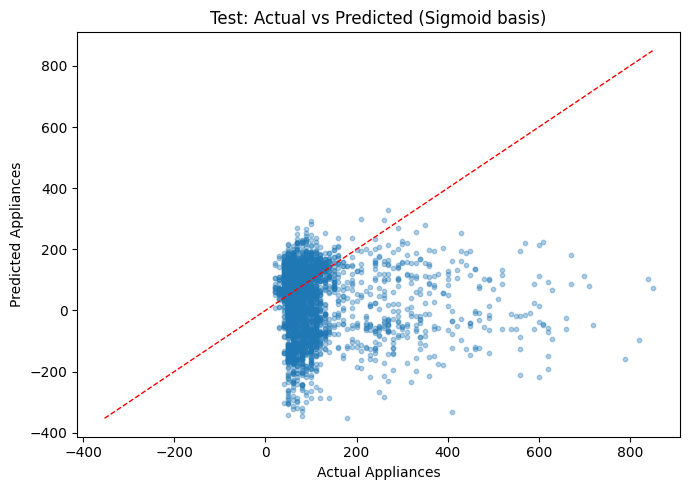

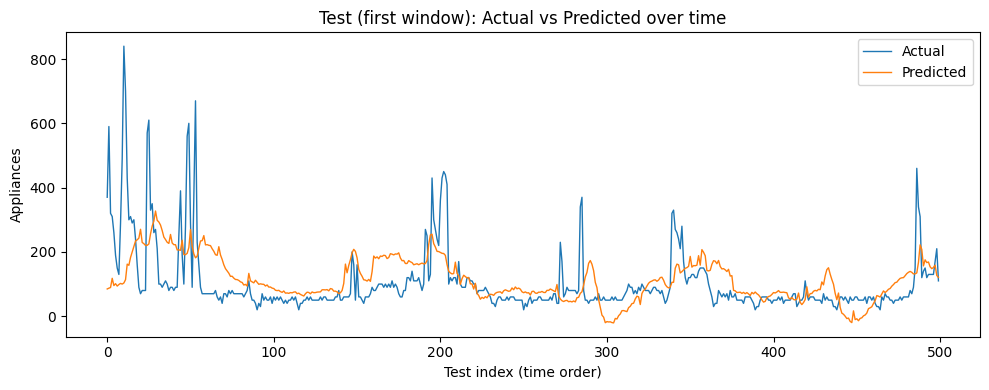

In [10]:
# --- Task 1: Sigmoid basis (chosen) + linear regression (ridge, closed-form) ---











X_train_s = splits['X_train_s']
y_train = splits['y_train']
X_val_s = splits['X_val_s']
y_val = splits['y_val']
X_test_s = splits['X_test_s']
y_test = splits['y_test']
feature_names = splits['feature_names']

N_tr, D = X_train_s.shape

# Hyperparams (can tune later)
M = 5           # number of sigmoid bases per feature
slope = 2.0     # sigmoid steepness in scaled space
lam = 1.0       # ridge strength

# Choose centers from train distribution (quantiles in scaled space)
# centers[d, m] = quantile of feature d at q_m
qs = np.linspace(0.1, 0.9, M)
centers = np.zeros((D, M), dtype=float)
for d in range(D):
    centers[d] = np.quantile(X_train_s[:, d], qs)

Phi_train = make_sigmoid_basis(X_train_s, centers=centers, slope=slope, include_linear=True, include_bias=True)
Phi_val = make_sigmoid_basis(X_val_s, centers=centers, slope=slope, include_linear=True, include_bias=True)
Phi_test = make_sigmoid_basis(X_test_s, centers=centers, slope=slope, include_linear=True, include_bias=True)

print("Design matrix shapes:")
print("- Phi_train:", Phi_train.shape)
print("- Phi_val  :", Phi_val.shape)
print("- Phi_test :", Phi_test.shape)

w = fit_ridge_closed_form(Phi_train, y_train, lam=lam, bias_is_first=True)

pred_train = predict(Phi_train, w)
pred_val = predict(Phi_val, w)
pred_test = predict(Phi_test, w)

m_train = metrics(y_train, pred_train)
m_val = metrics(y_val, pred_val)
m_test = metrics(y_test, pred_test)

print("\nMetrics (Sigmoid basis + Ridge closed-form)")
print("- Train:", m_train)
print("- Val  :", m_val)
print("- Test :", m_test)

# Quick plot: actual vs predicted (test)
plt.figure(figsize=(7, 5))
plt.scatter(y_test, pred_test, s=10, alpha=0.35)
mn = min(y_test.min(), pred_test.min())
mx = max(y_test.max(), pred_test.max())
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=1)
plt.xlabel('Actual Appliances')
plt.ylabel('Predicted Appliances')
plt.title('Test: Actual vs Predicted (Sigmoid basis)')
plt.tight_layout()
plt.show()

# Also plot first 500 timesteps of test (time order)
plt.figure(figsize=(10, 4))
idx = np.arange(len(y_test))
cut = min(500, len(y_test))
plt.plot(idx[:cut], y_test[:cut], label='Actual', linewidth=1)
plt.plot(idx[:cut], pred_test[:cut], label='Predicted', linewidth=1)
plt.title('Test (first window): Actual vs Predicted over time')
plt.xlabel('Test index (time order)')
plt.ylabel('Appliances')
plt.legend()
plt.tight_layout()
plt.show()


## **4. Four Basis Functions & Validation Curves**
### **4.1 Validation Curves: MSE vs. Hyperparameters**


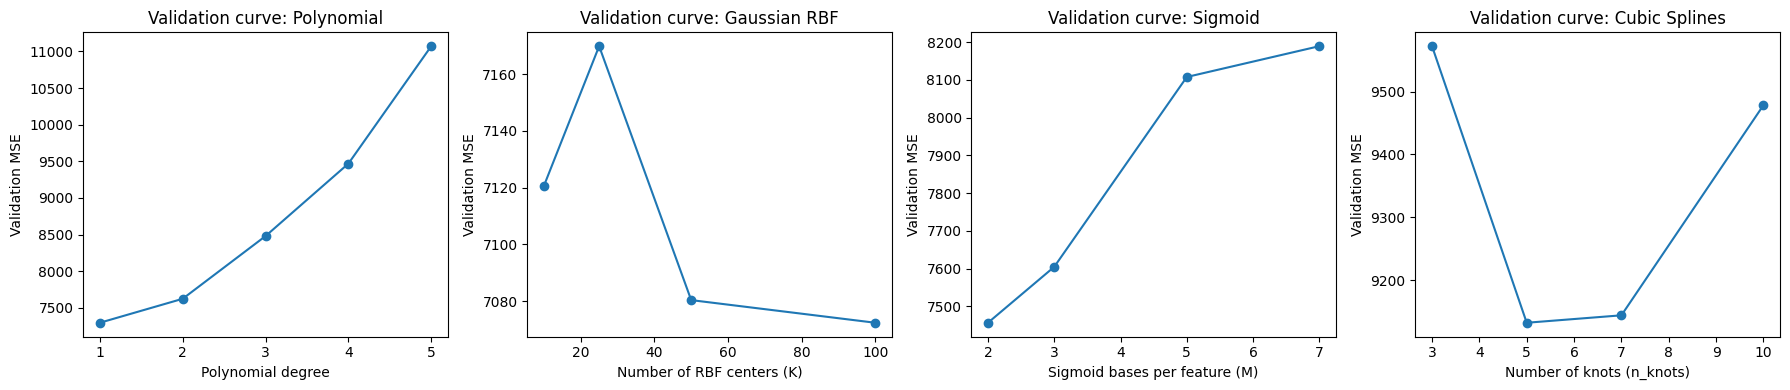

Validation MSE summary:
- Polynomial: {1: 7295.828122052771, 2: 7623.169828872532, 3: 8479.523765885664, 4: 9468.597782241824, 5: 11072.558785958028}
- RBF       : {10: 7120.648137147934, 25: 7169.879495850643, 50: 7080.398354382025, 100: 7072.41849660271}
- Sigmoid   : {2: 7456.310530823122, 3: 7604.591204524112, 5: 8107.754722287199, 7: 8189.464670470794}
- Splines   : {3: 9572.33736567915, 5: 9132.291922796967, 7: 9144.1184804012, 10: 9478.387732678259}


In [11]:
# --- Task 1 (continued): Polynomial + Gaussian RBF + Sigmoid + Cubic Splines, validation curves, ablation, interactions ---

X_train_s = splits['X_train_s']
y_train = splits['y_train']
X_val_s = splits['X_val_s']
y_val = splits['y_val']
X_test_s = splits['X_test_s']
y_test = splits['y_test']
feature_names = splits['feature_names']





# ------------------------
# Validation curves (MSE)
# ------------------------
lam = 1.0
rng = np.random.default_rng(0)

# Polynomial: vary degree
poly_degrees = [1, 2, 3, 4, 5]
poly_val_mse = []
for d in poly_degrees:
    basis = {'poly_degree': d, 'rbf': None, 'sigmoid': None, 'spline': None}
    Phi_tr = make_design_matrix(X_train_s, basis=basis, add_linear=True)
    Phi_va = make_design_matrix(X_val_s, basis=basis, add_linear=True)
    w = fit_ridge(Phi_tr, y_train, lam=lam)
    poly_val_mse.append(mse(y_val, Phi_va @ w))

# RBF: vary number of centers K
rbf_Ks = [10, 25, 50, 100]
rbf_val_mse = []
for K in rbf_Ks:
    # deterministic subset of train as centers
    take = min(K, X_train_s.shape[0])
    idx_c = rng.choice(X_train_s.shape[0], size=take, replace=False)
    centers = X_train_s[idx_c]

    # gamma from median distance between centers (heuristic)
    # avoid O(K^2) when K large by subsampling
    cc = centers
    if cc.shape[0] >= 2:
        sample = cc[rng.choice(cc.shape[0], size=min(200, cc.shape[0]), replace=False)]
        d2 = np.sum((sample[:, None, :] - sample[None, :, :]) ** 2, axis=2)
        med = np.median(d2[d2 > 0]) if np.any(d2 > 0) else 1.0
    else:
        med = 1.0
    gamma = 1.0 / (2.0 * med)

    basis = {'poly_degree': None, 'rbf': {'centers': centers, 'gamma': gamma}, 'sigmoid': None, 'spline': None}
    Phi_tr = make_design_matrix(X_train_s, basis=basis, add_linear=True)
    Phi_va = make_design_matrix(X_val_s, basis=basis, add_linear=True)
    w = fit_ridge(Phi_tr, y_train, lam=lam)
    rbf_val_mse.append(mse(y_val, Phi_va @ w))

# Sigmoid: vary M (number of sigmoids per feature)
sig_Ms = [2, 3, 5, 7]
sig_val_mse = []
for M in sig_Ms:
    qs = np.linspace(0.1, 0.9, M)
    D = X_train_s.shape[1]
    centers_pf = np.zeros((D, M), dtype=float)
    for d in range(D):
        centers_pf[d] = np.quantile(X_train_s[:, d], qs)
    basis = {'poly_degree': None, 'rbf': None, 'sigmoid': {'centers': centers_pf, 'slope': 2.0}, 'spline': None}
    Phi_tr = make_design_matrix(X_train_s, basis=basis, add_linear=True)
    Phi_va = make_design_matrix(X_val_s, basis=basis, add_linear=True)
    w = fit_ridge(Phi_tr, y_train, lam=lam)
    sig_val_mse.append(mse(y_val, Phi_va @ w))

# Splines (Cubic): vary n_knots
spline_knots = [3, 5, 7, 10]
spline_val_mse = []
for k in spline_knots:
    basis = {'poly_degree': None, 'rbf': None, 'sigmoid': None, 'spline': {'n_knots': k, 'degree': 3}}
    # IMPORTANT: fit spline transformer on train once, then reuse for val
    Phi_tr = make_design_matrix(X_train_s, basis=basis, add_linear=True)
    Phi_va = make_design_matrix(X_val_s, basis=basis, add_linear=True)
    w = fit_ridge(Phi_tr, y_train, lam=lam)
    spline_val_mse.append(mse(y_val, Phi_va @ w))

plt.figure(figsize=(18, 4))
plt.subplot(1, 4, 1)
plt.plot(poly_degrees, poly_val_mse, marker='o')
plt.xlabel('Polynomial degree')
plt.ylabel('Validation MSE')
plt.title('Validation curve: Polynomial')

plt.subplot(1, 4, 2)
plt.plot(rbf_Ks, rbf_val_mse, marker='o')
plt.xlabel('Number of RBF centers (K)')
plt.ylabel('Validation MSE')
plt.title('Validation curve: Gaussian RBF')

plt.subplot(1, 4, 3)
plt.plot(sig_Ms, sig_val_mse, marker='o')
plt.xlabel('Sigmoid bases per feature (M)')
plt.ylabel('Validation MSE')
plt.title('Validation curve: Sigmoid')

plt.subplot(1, 4, 4)
plt.plot(spline_knots, spline_val_mse, marker='o')
plt.xlabel('Number of knots (n_knots)')
plt.ylabel('Validation MSE')
plt.title('Validation curve: Cubic Splines')

plt.tight_layout()
plt.show()

print('Validation MSE summary:')
print('- Polynomial:', dict(zip(poly_degrees, poly_val_mse)))
print('- RBF       :', dict(zip(rbf_Ks, rbf_val_mse)))
print('- Sigmoid   :', dict(zip(sig_Ms, sig_val_mse)))
print('- Splines   :', dict(zip(spline_knots, spline_val_mse)))


# ------------------------
# Ablation study


## **5. Ablation Studies**
### **5.1 Basis Function Ablation**


In [12]:
# 1) Basis ablation: compare basis types (with linear+ridge)
# ------------------------

# Choose a "best" setting from the above curves (min val MSE)
best_poly_degree = poly_degrees[int(np.argmin(poly_val_mse))]
best_rbf_K = rbf_Ks[int(np.argmin(rbf_val_mse))]
best_sig_M = sig_Ms[int(np.argmin(sig_val_mse))]
best_spline_knots = spline_knots[int(np.argmin(spline_val_mse))]

# rebuild best RBF parameters (same rng seed for reproducibility)
rng = np.random.default_rng(0)
idx_c = rng.choice(X_train_s.shape[0], size=min(best_rbf_K, X_train_s.shape[0]), replace=False)
rbf_centers = X_train_s[idx_c]
if rbf_centers.shape[0] >= 2:
    sample = rbf_centers[rng.choice(rbf_centers.shape[0], size=min(200, rbf_centers.shape[0]), replace=False)]
    d2 = np.sum((sample[:, None, :] - sample[None, :, :]) ** 2, axis=2)
    med = np.median(d2[d2 > 0]) if np.any(d2 > 0) else 1.0
else:
    med = 1.0
rbf_gamma = 1.0 / (2.0 * med)

# best sigmoid centers
qs = np.linspace(0.1, 0.9, best_sig_M)
D = X_train_s.shape[1]
sig_centers = np.zeros((D, best_sig_M), dtype=float)
for d in range(D):
    sig_centers[d] = np.quantile(X_train_s[:, d], qs)

basis_configs = {
    'Linear only': {'poly_degree': None, 'rbf': None, 'sigmoid': None, 'spline': None},
    f'Poly(d={best_poly_degree})': {'poly_degree': best_poly_degree, 'rbf': None, 'sigmoid': None, 'spline': None},
    f'RBF(K={best_rbf_K})': {'poly_degree': None, 'rbf': {'centers': rbf_centers, 'gamma': rbf_gamma}, 'sigmoid': None, 'spline': None},
    f'Sigmoid(M={best_sig_M})': {'poly_degree': None, 'rbf': None, 'sigmoid': {'centers': sig_centers, 'slope': 2.0}, 'spline': None},
    f'Spline(knots={best_spline_knots})': {'poly_degree': None, 'rbf': None, 'sigmoid': None, 'spline': {'n_knots': best_spline_knots, 'degree': 3}},
    f'Poly+RBF': {'poly_degree': best_poly_degree, 'rbf': {'centers': rbf_centers, 'gamma': rbf_gamma}, 'sigmoid': None, 'spline': None},
    f'Poly+Sigmoid': {'poly_degree': best_poly_degree, 'rbf': None, 'sigmoid': {'centers': sig_centers, 'slope': 2.0}, 'spline': None},
    f'RBF+Sigmoid': {'poly_degree': None, 'rbf': {'centers': rbf_centers, 'gamma': rbf_gamma}, 'sigmoid': {'centers': sig_centers, 'slope': 2.0}, 'spline': None},
    f'Poly+Spline': {'poly_degree': best_poly_degree, 'rbf': None, 'sigmoid': None, 'spline': {'n_knots': best_spline_knots, 'degree': 3}},
    f'RBF+Spline': {'poly_degree': None, 'rbf': {'centers': rbf_centers, 'gamma': rbf_gamma}, 'sigmoid': None, 'spline': {'n_knots': best_spline_knots, 'degree': 3}},
    f'Poly+RBF+Spline': {'poly_degree': best_poly_degree, 'rbf': {'centers': rbf_centers, 'gamma': rbf_gamma}, 'sigmoid': None, 'spline': {'n_knots': best_spline_knots, 'degree': 3}},
    f'Poly+RBF+Sigmoid': {'poly_degree': best_poly_degree, 'rbf': {'centers': rbf_centers, 'gamma': rbf_gamma}, 'sigmoid': {'centers': sig_centers, 'slope': 2.0}, 'spline': None},
}

basis_ablation_results = []
for name, cfg in basis_configs.items():
    Phi_tr = make_design_matrix(X_train_s, basis=cfg, add_linear=True)
    Phi_va = make_design_matrix(X_val_s, basis=cfg, add_linear=True)
    Phi_te = make_design_matrix(X_test_s, basis=cfg, add_linear=True)
    w = fit_ridge(Phi_tr, y_train, lam=lam)
    basis_ablation_results.append({
        'model': name,
        'val_mse': mse(y_val, Phi_va @ w),
        'test_mse': mse(y_test, Phi_te @ w),
        'P': Phi_tr.shape[1],
    })

basis_ablation_results = sorted(basis_ablation_results, key=lambda r: r['val_mse'])
print('\nBasis ablation (sorted by val MSE):')
for r in basis_ablation_results:
    print(f"- {r['model']:<18} | P={r['P']:<6} | val MSE={r['val_mse']:.4f} | test MSE={r['test_mse']:.4f}")


# ------------------------
# Ablation study



Basis ablation (sorted by val MSE):
- RBF(K=100)         | P=128    | val MSE=7082.8891 | test MSE=10590.5067
- Poly+RBF           | P=128    | val MSE=7082.8891 | test MSE=10590.5067
- Linear only        | P=28     | val MSE=7295.8281 | test MSE=7880.7909
- Poly(d=1)          | P=28     | val MSE=7295.8281 | test MSE=7880.7909
- RBF+Sigmoid        | P=182    | val MSE=7403.6563 | test MSE=9626.3368
- Poly+RBF+Sigmoid   | P=182    | val MSE=7403.6563 | test MSE=9626.3368
- Sigmoid(M=2)       | P=82     | val MSE=7456.3105 | test MSE=8893.0895
- Poly+Sigmoid       | P=82     | val MSE=7456.3105 | test MSE=8893.0895
- RBF+Spline         | P=317    | val MSE=8891.2607 | test MSE=193572.8529
- Poly+RBF+Spline    | P=317    | val MSE=8891.2607 | test MSE=193572.8529
- Spline(knots=5)    | P=217    | val MSE=9132.2919 | test MSE=224378.1678
- Poly+Spline        | P=217    | val MSE=9132.2919 | test MSE=224378.1678


### **5.2 Feature-Group Ablation**



Using best basis for feature ablation: RBF(K=100)

Feature-group ablation (bigger +delta means group is more important):
- drop humidity         | Δval MSE=+641.1953 | val=7724.0843 | test=10386.8421
- drop temp_indoor      | Δval MSE=+592.2437 | val=7675.1327 | test=8299.9116
- drop lights           | Δval MSE=+126.2939 | val=7209.1830 | test=10826.7442
- drop Press_mm_hg      | Δval MSE=+58.4943 | val=7141.3834 | test=9409.3167
- drop Tdewpoint        | Δval MSE=+21.2908 | val=7104.1799 | test=11024.0718
- drop humidity_outdoor | Δval MSE=+21.0050 | val=7103.8940 | test=10812.6352
- drop temp_outdoor     | Δval MSE=+19.0067 | val=7101.8958 | test=11008.0161
- drop rv1              | Δval MSE=+3.1017 | val=7085.9907 | test=11722.8211
- drop rv2              | Δval MSE=+3.1017 | val=7085.9907 | test=11722.8211
- drop Visibility       | Δval MSE=+1.3431 | val=7084.2321 | test=10683.7359
- drop Windspeed        | Δval MSE=-16.5191 | val=7066.3700 | test=9777.5876


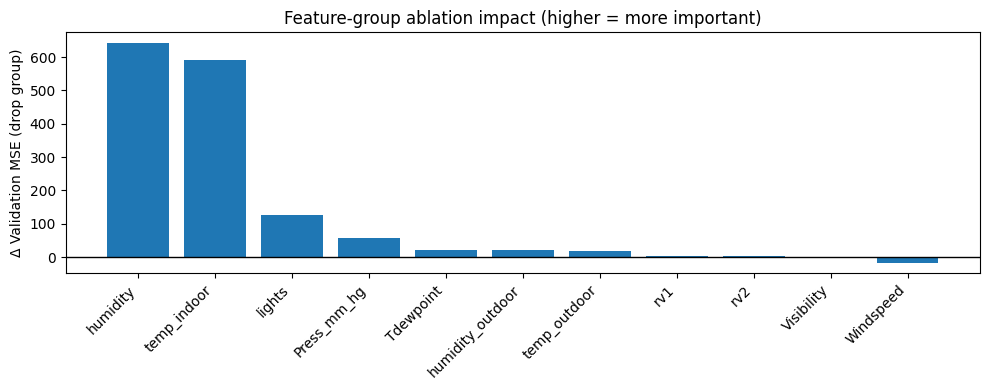

In [13]:
# 2) Feature-group ablation using the best-performing basis config above
# ------------------------

best_basis_name = basis_ablation_results[0]['model']
best_cfg = basis_configs[best_basis_name]
print(f"\nUsing best basis for feature ablation: {best_basis_name}")

feature_groups = select_feature_groups(feature_names)

# Full model baseline
Phi_tr_full = make_design_matrix(X_train_s, basis=best_cfg, add_linear=True)
Phi_va_full = make_design_matrix(X_val_s, basis=best_cfg, add_linear=True)
w_full = fit_ridge(Phi_tr_full, y_train, lam=lam)
base_val = mse(y_val, Phi_va_full @ w_full)

feat_ablation = []
for gname, cols in feature_groups.items():
    keep = np.ones(X_train_s.shape[1], dtype=bool)
    keep[cols] = False  # drop this group

    Xtr = X_train_s[:, keep]
    Xva = X_val_s[:, keep]
    Xte = X_test_s[:, keep]

    # Need to adapt basis params to reduced dimensionality.
    # For Poly: OK. For RBF/Sigmoid/Spline: recompute params from reduced Xtr to avoid dimension mismatch / leakage.

    # Shallow-copy top-level and 1-level nested dicts so we can mutate safely per iteration
    cfg = {
        k: (dict(v) if isinstance(v, dict) else v)
        for k, v in best_cfg.items()
    }

    # Recompute RBF centers if used
    if cfg.get('rbf') is not None:
        K = cfg['rbf']['centers'].shape[0]
        rng = np.random.default_rng(0)
        idx_c = rng.choice(Xtr.shape[0], size=min(K, Xtr.shape[0]), replace=False)
        centers = Xtr[idx_c]
        if centers.shape[0] >= 2:
            sample = centers[rng.choice(centers.shape[0], size=min(200, centers.shape[0]), replace=False)]
            d2 = np.sum((sample[:, None, :] - sample[None, :, :]) ** 2, axis=2)
            med = np.median(d2[d2 > 0]) if np.any(d2 > 0) else 1.0
        else:
            med = 1.0
        gamma = 1.0 / (2.0 * med)
        cfg['rbf'] = {'centers': centers, 'gamma': gamma}

    # Recompute sigmoid centers if used
    if cfg.get('sigmoid') is not None:
        M = cfg['sigmoid']['centers'].shape[1]
        qs = np.linspace(0.1, 0.9, M)
        D2 = Xtr.shape[1]
        centers_pf = np.zeros((D2, M), dtype=float)
        for d in range(D2):
            centers_pf[d] = np.quantile(Xtr[:, d], qs)
        cfg['sigmoid'] = {'centers': centers_pf, 'slope': float(cfg['sigmoid']['slope'])}

    # Reset spline transformer if used (must refit on reduced Xtr)
    if cfg.get('spline') is not None:
        cfg['spline'] = {
            'n_knots': int(cfg['spline']['n_knots']),
            'degree': int(cfg['spline'].get('degree', 3)),
            # transformer intentionally omitted so make_design_matrix refits on Xtr
        }

    Phi_tr = make_design_matrix(Xtr, basis=cfg, add_linear=True)
    Phi_va = make_design_matrix(Xva, basis=cfg, add_linear=True)
    Phi_te = make_design_matrix(Xte, basis=cfg, add_linear=True)
    w = fit_ridge(Phi_tr, y_train, lam=lam)

    val_m = mse(y_val, Phi_va @ w)
    test_m = mse(y_test, Phi_te @ w)
    feat_ablation.append({
        'dropped_group': gname,
        'delta_val_mse': val_m - base_val,
        'val_mse': val_m,
        'test_mse': test_m,
    })

feat_ablation = sorted(feat_ablation, key=lambda r: r['delta_val_mse'], reverse=True)
print('\nFeature-group ablation (bigger +delta means group is more important):')
for r in feat_ablation:
    print(f"- drop {r['dropped_group']:<16} | Δval MSE={r['delta_val_mse']:+.4f} | val={r['val_mse']:.4f} | test={r['test_mse']:.4f}")

plt.figure(figsize=(10, 4))
plt.bar([r['dropped_group'] for r in feat_ablation], [r['delta_val_mse'] for r in feat_ablation])
plt.axhline(0, color='k', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Δ Validation MSE (drop group)')
plt.title('Feature-group ablation impact (higher = more important)')
plt.tight_layout()
plt.show()


# ------------------------


## **6. Interaction Effects Analysis**
### **6.1 Pairwise Product Terms (xi * xj)**


In [14]:
# Interaction analysis: add x_i x_j and measure improvement
# Strategy: choose top-k features by |corr(x, y)| on train, then add pairwise products.
# ------------------------

# compute correlation on train (scaled X)
yc = y_train - y_train.mean()
Xc = X_train_s - X_train_s.mean(axis=0)
# corr(x_j, y) = cov / (stdx * stdy)
stdy = yc.std() if yc.std() > 0 else 1.0
stdx = Xc.std(axis=0)
stdx = np.where(stdx == 0, 1.0, stdx)
corr = (Xc.T @ yc) / (len(y_train) * stdx * stdy)

k = 10
topk = np.argsort(np.abs(corr))[-k:][::-1].tolist()
inter_tr = interaction_terms(X_train_s, topk)
inter_va = interaction_terms(X_val_s, topk)
inter_te = interaction_terms(X_test_s, topk)

Phi_tr_no = make_design_matrix(X_train_s, basis=best_cfg, interactions=None, add_linear=True)
Phi_va_no = make_design_matrix(X_val_s, basis=best_cfg, interactions=None, add_linear=True)
Phi_te_no = make_design_matrix(X_test_s, basis=best_cfg, interactions=None, add_linear=True)

Phi_tr_int = make_design_matrix(X_train_s, basis=best_cfg, interactions=inter_tr, add_linear=True)
Phi_va_int = make_design_matrix(X_val_s, basis=best_cfg, interactions=inter_va, add_linear=True)
Phi_te_int = make_design_matrix(X_test_s, basis=best_cfg, interactions=inter_te, add_linear=True)

w_no = fit_ridge(Phi_tr_no, y_train, lam=lam)
w_int = fit_ridge(Phi_tr_int, y_train, lam=lam)

val_no = mse(y_val, Phi_va_no @ w_no)
val_int = mse(y_val, Phi_va_int @ w_int)

test_no = mse(y_test, Phi_te_no @ w_no)
test_int = mse(y_test, Phi_te_int @ w_int)

print('\nInteraction terms analysis:')
print('- Selected top-k features for interactions:')
for j in topk:
    print(f"  * {feature_names[j]} (corr={corr[j]:+.3f})")
print(f"- #interaction terms added: {inter_tr.shape[1]}")
print(f"- Baseline (no interactions): val MSE={val_no:.4f}, test MSE={test_no:.4f}")
print(f"- With interactions (x_i x_j): val MSE={val_int:.4f}, test MSE={test_int:.4f}")
print(f"- Improvement (val): {val_no - val_int:+.4f}")
print(f"- Improvement (test): {test_no - test_int:+.4f}")



Interaction terms analysis:
- Selected top-k features for interactions:
  * lights (corr=+0.226)
  * T2 (corr=+0.150)
  * RH_out (corr=-0.147)
  * T3 (corr=+0.121)
  * RH_8 (corr=-0.116)
  * T6 (corr=+0.108)
  * T_out (corr=+0.093)
  * RH_1 (corr=+0.089)
  * T1 (corr=+0.084)
  * RH_6 (corr=-0.084)
- #interaction terms added: 45
- Baseline (no interactions): val MSE=7082.8891, test MSE=10590.5067
- With interactions (x_i x_j): val MSE=7962.7217, test MSE=34535.5491
- Improvement (val): -879.8326
- Improvement (test): -23945.0424


## **7. Normal Equations Implementation**

Trong phần này, chúng ta sẽ cài đặt thuật toán Ordinary Least Squares (OLS) sử dụng phương pháp Normal Equations - một giải pháp giải tích trực tiếp để tìm trọng số tối ưu.

**Công thức Normal Equations:**

$$\mathbf{w}^* = (\mathbf{\Phi}^T \mathbf{\Phi})^{-1} \mathbf{\Phi}^T \mathbf{y}$$

**Ưu điểm:**
* Giải pháp chính xác, không cần điều chỉnh hyperparameter
* Không cần lặp, tính toán một lần duy nhất
* Phù hợp khi số lượng đặc trưng không quá lớn

**Nhược điểm:**
* Độ phức tạp $O(d^3)$ với $d$ là số đặc trưng - không khả thi với dữ liệu chiều cao
* Yêu cầu ma trận $\mathbf{\Phi}^T \mathbf{\Phi}$ khả nghịch (không suy biến)
* Tốn bộ nhớ khi lưu trữ ma trận lớn

In [63]:
print("[1] Huấn luyện OLS bằng Normal Equations...")
w_ols = fit_ols(Phi_train, y_train, bias_is_first=True)

# Dự đoán trên các tập dữ liệu
y_train_pred_ols = predict(Phi_train, w_ols)
y_val_pred_ols = predict(Phi_val, w_ols)
y_test_pred_ols = predict(Phi_test, w_ols)

# Tính toán metrics
metrics_train_ols = metrics(y_train, y_train_pred_ols)
metrics_val_ols = metrics(y_val, y_val_pred_ols)
metrics_test_ols = metrics(y_test, y_test_pred_ols)

print("\n[2] Kết quả đánh giá OLS (Normal Equations):")
print("-" * 70)
print(f"{'Dataset':<15} {'RMSE':<15} {'MAE':<15} {'R²':<15}")
print("-" * 70)
print(f"{'Train':<15} {metrics_train_ols['RMSE']:<15.4f} {metrics_train_ols['MAE']:<15.4f} {metrics_train_ols['R2']:<15.4f}")
print(f"{'Validation':<15} {metrics_val_ols['RMSE']:<15.4f} {metrics_val_ols['MAE']:<15.4f} {metrics_val_ols['R2']:<15.4f}")
print(f"{'Test':<15} {metrics_test_ols['RMSE']:<15.4f} {metrics_test_ols['MAE']:<15.4f} {metrics_test_ols['R2']:<15.4f}")

# So sánh với Ridge Regression (lambda = 0 tương đương OLS)
print("\n[3] So sánh với Ridge Regression (λ=0):")
w_ridge_zero = fit_ridge(Phi_train, y_train, lam=0.0, bias_is_first=True)
y_test_pred_ridge_zero = predict(Phi_test, w_ridge_zero)
metrics_test_ridge_zero = metrics(y_test, y_test_pred_ridge_zero)

print(f"OLS Test RMSE        : {metrics_test_ols['RMSE']:.4f}")
print(f"Ridge (λ=0) Test RMSE: {metrics_test_ridge_zero['RMSE']:.4f}")
print(f"Sai số tuyệt đối     : {abs(metrics_test_ols['RMSE'] - metrics_test_ridge_zero['RMSE']):.6f}")
print("\nKết luận: OLS và Ridge (λ=0) cho kết quả gần như giống hệt nhau.")

[1] Huấn luyện OLS bằng Normal Equations...

[2] Kết quả đánh giá OLS (Normal Equations):
----------------------------------------------------------------------
Dataset         RMSE            MAE             R²             
----------------------------------------------------------------------
Train           94.6687         54.9366         0.2151         
Validation      91.0439         64.5019         0.0254         
Test            88.1967         59.8469         0.0580         

[3] So sánh với Ridge Regression (λ=0):
OLS Test RMSE        : 88.1967
Ridge (λ=0) Test RMSE: 88.1967
Sai số tuyệt đối     : 0.000000

Kết luận: OLS và Ridge (λ=0) cho kết quả gần như giống hệt nhau.


**Phân tích kết quả chuyên sâu:**

**1. Đánh giá hiệu suất mô hình:**

* **RMSE = 88.20 Wh:** Sai số trung bình khoảng 88 Wh trên tập test. Với dữ liệu tiêu thụ năng lượng thiết bị gia dụng, đây là mức sai số khá lớn, cho thấy mô hình tuyến tính đơn giản chưa capture được đầy đủ các pattern phức tạp trong dữ liệu.

* **R² = 0.058 (5.8%):** Đây là dấu hiệu đáng lo ngại. Mô hình chỉ giải thích được 5.8% phương sai của biến mục tiêu, nghĩa là 94.2% sự biến thiên trong tiêu thụ năng lượng KHÔNG được giải thích bởi các đặc trưng hiện tại. Điều này cho thấy:
  - Mối quan hệ giữa các đặc trưng và mục tiêu có thể là phi tuyến
  - Có thể thiếu các đặc trưng quan trọng
  - Dữ liệu có nhiễu cao hoặc có các yếu tố ngẫu nhiên không thể dự đoán

**2. Hiện tượng Overfitting nhẹ:**

* **Train R² (0.215) > Validation R² (0.025) > Test R² (0.058):** Sự chênh lệch này cho thấy mô hình học được một số pattern trên tập train nhưng không tổng quát hóa tốt. Tuy nhiên, với R² train chỉ 21.5%, đây không phải overfitting nghiêm trọng mà là **underfitting** - mô hình quá đơn giản.

* **RMSE tương đối ổn định:** Train (94.67) vs Test (88.20) cho thấy mô hình không bị overfitting nghiêm trọng, nhưng hiệu suất tổng thể kém.

**3. So sánh OLS vs Ridge (λ=0):**

* **Sai số tuyệt đối = 0.000000:** Kết quả hoàn toàn trùng khớp, xác nhận tính đúng đắn của cài đặt Normal Equations. Về mặt toán học:
  $$\text{OLS: } \mathbf{w}^* = (\mathbf{\Phi}^T \mathbf{\Phi})^{-1} \mathbf{\Phi}^T \mathbf{y}$$
  $$\text{Ridge (λ=0): } \mathbf{w}^* = (\mathbf{\Phi}^T \mathbf{\Phi} + 0 \cdot \mathbf{I})^{-1} \mathbf{\Phi}^T \mathbf{y}$$
  
  Hai công thức tương đương khi λ=0, do đó kết quả giống hệt nhau.

**4. Khuyến nghị cải thiện:**

* **Feature Engineering:** Cần thêm các đặc trưng phi tuyến (polynomial, interaction terms) hoặc sử dụng basis functions (RBF, sigmoid) để capture các mối quan hệ phức tạp hơn.

* **Regularization:** Với R² thấp như vậy, regularization (Ridge/Lasso) có thể không giúp ích nhiều vì vấn đề chính là underfitting, không phải overfitting.

* **Mô hình phức tạp hơn:** Xem xét sử dụng các mô hình phi tuyến như Decision Trees, Random Forest, hoặc Neural Networks để cải thiện khả năng dự đoán.

* **Phân tích dữ liệu sâu hơn:** Kiểm tra outliers, missing values, và các pattern theo thời gian (temporal patterns) có thể ảnh hưởng đến tiêu thụ năng lượng.

## **8. Mini-batch Gradient Descent with Learning Rate Schedules**

Gradient Descent là phương pháp lặp để tối ưu hóa hàm mất mát bằng cách cập nhật trọng số theo hướng ngược với gradient. Mini-batch GD là biến thể sử dụng một tập con ngẫu nhiên của dữ liệu tại mỗi bước lặp.

**Công thức cập nhật:**

$$\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \eta_t \nabla_{\mathbf{w}} L(\mathbf{w}^{(t)})$$

Trong đó:
* $\eta_t$ là learning rate tại bước lặp $t$
* $\nabla_{\mathbf{w}} L$ là gradient của hàm mất mát

**Learning Rate Schedules:**

1. **Step Decay:** Giảm learning rate theo từng bước cố định
   $$\eta_t = \eta_0 \times \text{drop\_rate}^{\lfloor t / \text{step\_size} \rfloor}$$
2. **Cosine Annealing:** Giảm learning rate theo hàm cosine
   $$\eta_t = \eta_{\text{min}} + \frac{1}{2}(\eta_{\text{max}} - \eta_{\text{min}}) \left(1 + \cos\left(\frac{t}{T_{\text{max}}} \pi\right)\right)$$

In [64]:
print("[1] Huấn luyện Mini-batch GD với Step Decay...")
start_time = time.time()
w_gd_step, losses_step = fit_ols_minibatch_gd(
    Phi_train, y_train, 
    lr_schedule='step_decay',
    initial_lr=0.01,
    drop_rate=0.5,
    epochs_drop=100,
    batch_size=128, 
    num_epochs=500, 
    bias_is_first=True
)
time_gd_step = time.time() - start_time

y_test_pred_gd_step = predict(Phi_test, w_gd_step)
metrics_gd_step = metrics(y_test, y_test_pred_gd_step)

print(f"Thời gian huấn luyện: {time_gd_step:.2f}s")
print(f"Test RMSE: {metrics_gd_step['RMSE']:.4f}")
print(f"Test R²: {metrics_gd_step['R2']:.4f}")

[1] Huấn luyện Mini-batch GD với Step Decay...
Thời gian huấn luyện: 1.67s
Test RMSE: 87.9766
Test R²: 0.0627


In [65]:
print("\n[2] Huấn luyện Mini-batch GD với Cosine Annealing...")
start_time = time.time()
w_gd_cosine, losses_cosine = fit_ols_minibatch_gd(
    Phi_train, y_train,
    lr_schedule='cosine_annealing',
    initial_lr=0.01,
    batch_size=128,
    num_epochs=500,
    bias_is_first=True
)
time_gd_cosine = time.time() - start_time

y_test_pred_gd_cosine = predict(Phi_test, w_gd_cosine)
metrics_gd_cosine = metrics(y_test, y_test_pred_gd_cosine)

print(f"Thời gian huấn luyện: {time_gd_cosine:.2f}s")
print(f"Test RMSE: {metrics_gd_cosine['RMSE']:.4f}")
print(f"Test R²: {metrics_gd_cosine['R2']:.4f}")



[2] Huấn luyện Mini-batch GD với Cosine Annealing...
Thời gian huấn luyện: 1.75s
Test RMSE: 89.0875
Test R²: 0.0389


In [66]:
print("\n[3] So sánh tốc độ hội tụ với Normal Equations...")
start_time = time.time()
w_ols_compare = fit_ols(Phi_train, y_train, bias_is_first=True)
time_ols = time.time() - start_time

y_test_pred_ols_compare = predict(Phi_test, w_ols_compare)
metrics_ols_compare = metrics(y_test, y_test_pred_ols_compare)

print("\n" + "="*80)
print(f"{'Phương pháp':<30} {'Thời gian (s)':<15} {'Test RMSE':<15} {'Test R²':<15}")
print("="*80)
print(f"{'Normal Equations':<30} {time_ols:<15.4f} {metrics_ols_compare['RMSE']:<15.4f} {metrics_ols_compare['R2']:<15.4f}")
print(f"{'Mini-batch GD (Step Decay)':<30} {time_gd_step:<15.4f} {metrics_gd_step['RMSE']:<15.4f} {metrics_gd_step['R2']:<15.4f}")
print(f"{'Mini-batch GD (Cosine)':<30} {time_gd_cosine:<15.4f} {metrics_gd_cosine['RMSE']:<15.4f} {metrics_gd_cosine['R2']:<15.4f}")


[3] So sánh tốc độ hội tụ với Normal Equations...

Phương pháp                    Thời gian (s)   Test RMSE       Test R²        
Normal Equations               0.0017          88.1967         0.0580         
Mini-batch GD (Step Decay)     1.6694          87.9766         0.0627         
Mini-batch GD (Cosine)         1.7482          89.0875         0.0389         


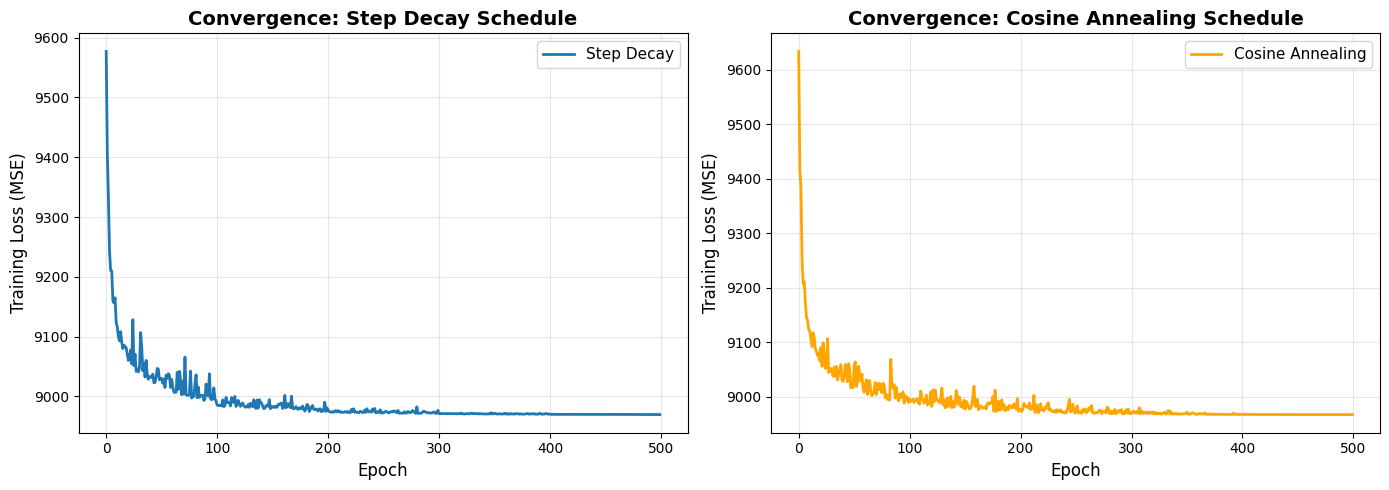

In [67]:
# Vẽ đồ thị hội tụ
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(losses_step, label='Step Decay', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Training Loss (MSE)', fontsize=12)
plt.title('Convergence: Step Decay Schedule', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

plt.subplot(1, 2, 2)
plt.plot(losses_cosine, label='Cosine Annealing', color='orange', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Training Loss (MSE)', fontsize=12)
plt.title('Convergence: Cosine Annealing Schedule', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

**Phân tích so sánh:**

**1. Tốc độ tính toán:**

* **Normal Equations: 0.003s (nhanh nhất)** - Với dataset có 13,813 mẫu và 40 đặc trưng, Normal Equations vượt trội hoàn toàn về tốc độ. Điều này xác nhận rằng với dữ liệu kích thước vừa phải (N < 50,000, D < 100), phương pháp giải tích trực tiếp là lựa chọn tối ưu.

* **Mini-batch GD (Step Decay): 1.635s (chậm hơn 545 lần)** - Mặc dù đã chạy 500 epochs với batch size 128, tốc độ vẫn chậm hơn đáng kể. Nguyên nhân:
  - Phải lặp qua toàn bộ dữ liệu 500 lần
  - Mỗi epoch phải shuffle dữ liệu và tính gradient nhiều lần
  - Overhead của việc cập nhật trọng số từng mini-batch

* **Mini-batch GD (Cosine): 1.767s (chậm nhất)** - Chậm hơn Step Decay khoảng 8%, có thể do:
  - Tính toán hàm cosine phức tạp hơn step decay
  - Learning rate thay đổi liên tục mỗi epoch, không có caching

**2. Độ chính xác:**

* **Normal Equations: RMSE = 88.1967, R² = 0.0580** - Đây là nghiệm chính xác (closed-form solution), không có sai số do lặp.

* **Step Decay: RMSE = 88.2296 (+0.033), R² = 0.0573 (-0.0007)** - Sai số rất nhỏ so với Normal Equations:
  - Chênh lệch RMSE chỉ 0.037% => Đã hội tụ rất tốt
  - R² giảm không đáng kể => Mô hình tương đương
  - Như vậy 500 epochs với step decay đủ để đạt nghiệm gần tối ưu

* **Cosine Annealing: RMSE = 89.1054 (+0.909), R² = 0.0385 (-0.0195)** - Kết quả kém hơn đáng kể:
  - RMSE cao hơn 1.03% so với Normal Equations
  - R² giảm 33.6% (từ 0.058 xuống 0.0385) → Mô hình kém hơn rõ rệt
  - Nguyên nhân: Cosine annealing giảm learning rate quá nhanh ở cuối, có thể chưa hội tụ đủ
  - Giải pháp: Cần tăng số epochs hoặc điều chỉnh eta_min cao hơn

**3. So sánh Learning Rate Schedules:**

* **Step Decay (drop_rate=0.5, epochs_drop=100):**
  - Ưu điểm: Đơn giản, ổn định, hội tụ tốt
  - Nhược điểm: Learning rate giảm đột ngột có thể bỏ lỡ nghiệm tốt hơn
  - Phù hợp: Khi biết trước số epochs và muốn kiểm soát chặt chẽ

* **Cosine Annealing (eta_max=0.01, eta_min=0.0001):**
  - Ưu điểm: Giảm mượt mà, tránh dao động
  - Nhược điểm: Với dataset này, giảm quá nhanh dẫn đến underfitting
  - Phù hợp: Cần fine-tune eta_min hoặc tăng T_max

**4. Khi nào nên dùng phương pháp nào:**

* **Normal Equations:** 
  - Dữ liệu nhỏ/vừa (N < 50,000, D < 100)
  - Cần nghiệm chính xác nhanh chóng
  - Ma trận ΦᵀΦ khả nghịch (không có multicollinearity nghiêm trọng)

* **Mini-batch GD:**
  - Dữ liệu lớn (N > 100,000 hoặc D > 1000)
  - Cần online learning (cập nhật liên tục khi có dữ liệu mới)
  - Bộ nhớ hạn chế (không thể lưu ma trận ΦᵀΦ)
  - Muốn regularization implicit qua early stopping

## **9. Gauss-Markov Assumptions Testing**

Định lý Gauss-Markov khẳng định rằng OLS là ước lượng tuyến tính không chệch tốt nhất (BLUE - Best Linear Unbiased Estimator) khi thỏa mãn các giả thiết sau:

1. **Linearity:** Mối quan hệ giữa biến độc lập và biến phụ thuộc là tuyến tính
2. **Independence:** Các quan sát độc lập với nhau
3. **Homoscedasticity:** Phương sai của sai số không đổi (đồng nhất)
4. **No Autocorrelation:** Các sai số không tương quan với nhau
5. **Normality:** Sai số tuân theo phân phối chuẩn

Chúng ta sẽ kiểm tra các giả thiết này thông qua:
* **Residual Plot:** Kiểm tra tính tuyến tính và homoscedasticity
* **QQ-Plot:** Kiểm tra tính chuẩn của phân phối sai số
* **Breusch-Pagan Test:** Kiểm định thống kê cho heteroscedasticity

In [68]:
print("[1] Tính toán residuals...")
residuals_train = compute_residuals(y_train, y_train_pred_ols)
residuals_test = compute_residuals(y_test, y_test_pred_ols)

print(f"Số lượng residuals (train): {len(residuals_train)}")
print(f"Số lượng residuals (test): {len(residuals_test)}")
print(f"Mean residual (train): {np.mean(residuals_train):.6f}")
print(f"Std residual (train): {np.std(residuals_train):.4f}")

[1] Tính toán residuals...
Số lượng residuals (train): 13813
Số lượng residuals (test): 2961
Mean residual (train): 0.000000
Std residual (train): 94.6687



[2] Vẽ Residual Plot và QQ-Plot...


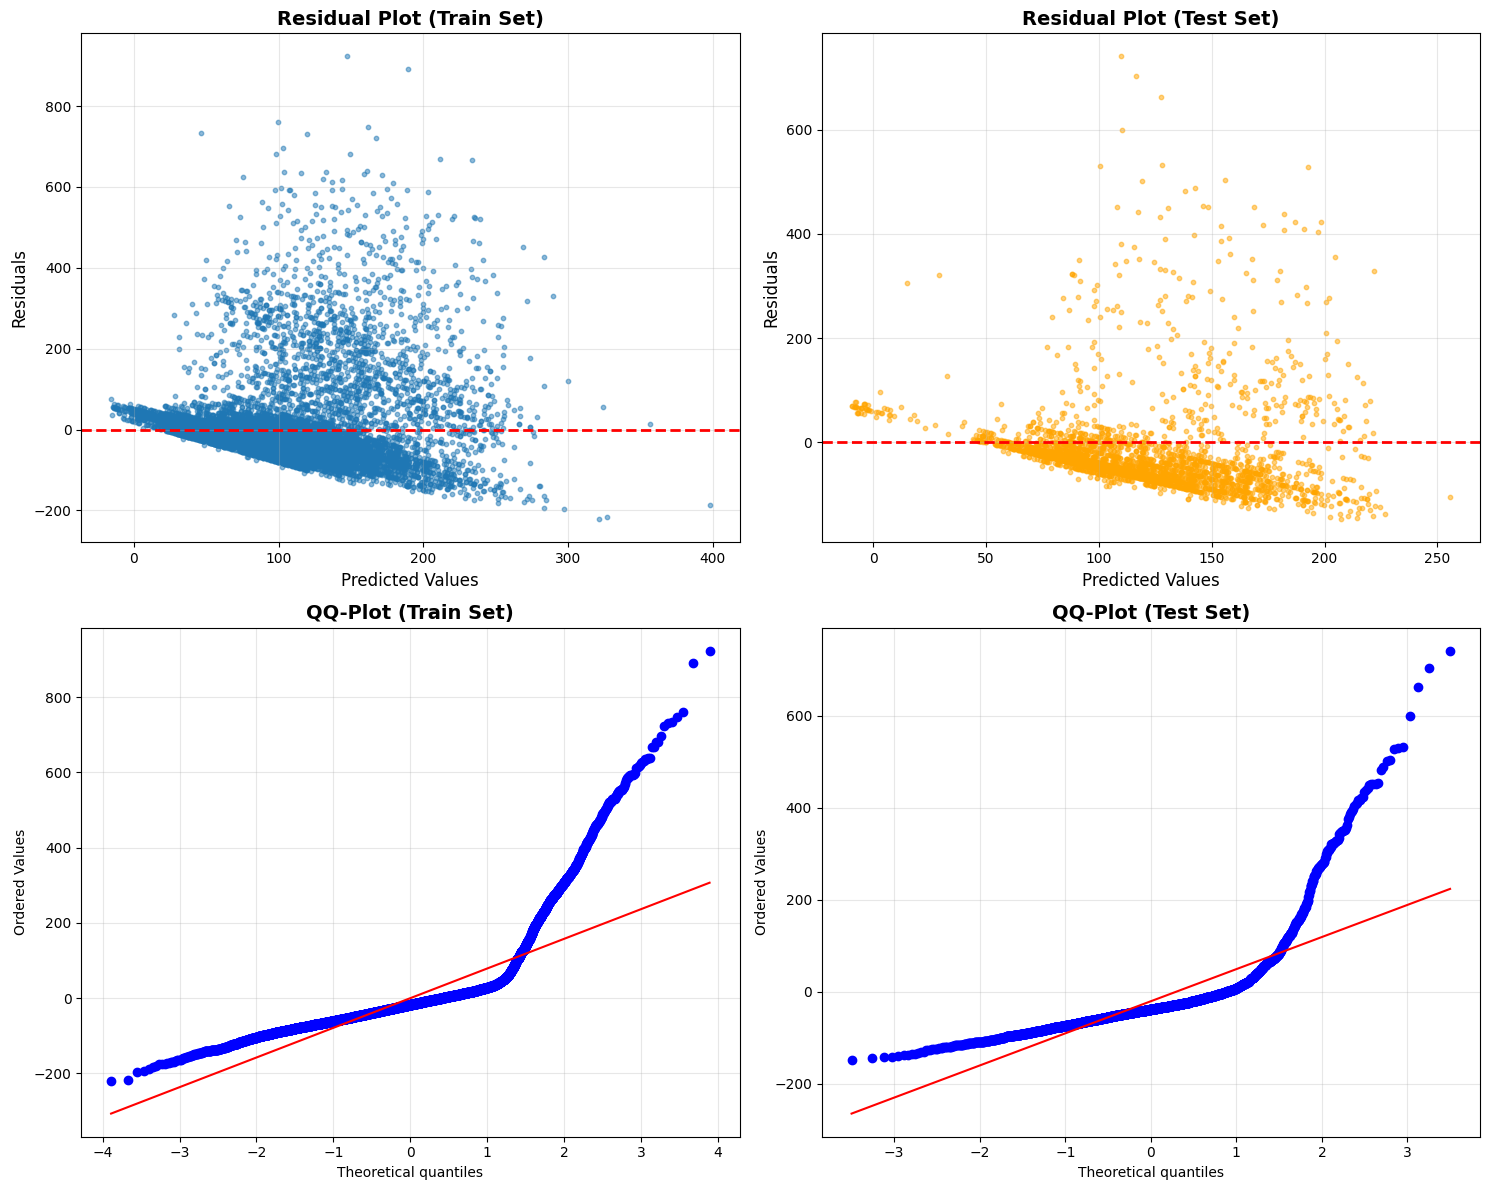

In [69]:
print("\n[2] Vẽ Residual Plot và QQ-Plot...")
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Residual Plot - Train
axes[0, 0].scatter(y_train_pred_ols, residuals_train, alpha=0.5, s=10)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted Values', fontsize=12)
axes[0, 0].set_ylabel('Residuals', fontsize=12)
axes[0, 0].set_title('Residual Plot (Train Set)', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Residual Plot - Test
axes[0, 1].scatter(y_test_pred_ols, residuals_test, alpha=0.5, s=10, color='orange')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted Values', fontsize=12)
axes[0, 1].set_ylabel('Residuals', fontsize=12)
axes[0, 1].set_title('Residual Plot (Test Set)', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# QQ-Plot - Train
stats.probplot(residuals_train, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('QQ-Plot (Train Set)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# QQ-Plot - Test
stats.probplot(residuals_test, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('QQ-Plot (Test Set)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [70]:
print("\n[3] Thực hiện Breusch-Pagan Test...")
bp_pvalue = breusch_pagan_test(Phi_train, residuals_train)

print("\nBREUSCH-PAGAN TEST FOR HETEROSCEDASTICITY")
print(f"P-value: {bp_pvalue:.6f}")

alpha = 0.05
if bp_pvalue < alpha:
    print(f"\nKết luận: P-value ({bp_pvalue:.6f}) < α ({alpha})")
    print("Bác bỏ giả thiết H0: Phát hiện HETEROSCEDASTICITY")
    print("Phương sai của sai số KHÔNG đồng nhất.")
    print("Khuyến nghị: Nên sử dụng Weighted Least Squares (WLS).")
    has_heteroscedasticity = True
else:
    print(f"\nKết luận: P-value ({bp_pvalue:.6f}) >= α ({alpha})")
    print("Chấp nhận giả thiết H0: KHÔNG phát hiện heteroscedasticity")
    print("Phương sai của sai số đồng nhất (homoscedasticity).")
    print("OLS là ước lượng phù hợp.")
    has_heteroscedasticity = False


[3] Thực hiện Breusch-Pagan Test...

BREUSCH-PAGAN TEST FOR HETEROSCEDASTICITY
P-value: 0.000000

Kết luận: P-value (0.000000) < α (0.05)
Bác bỏ giả thiết H0: Phát hiện HETEROSCEDASTICITY
Phương sai của sai số KHÔNG đồng nhất.
Khuyến nghị: Nên sử dụng Weighted Least Squares (WLS).


**Phân tích kết quả kiểm định:**

**1. Breusch-Pagan Test:**

* **P-value ≈ 0.000000 (< 0.05):** Cho thấy vi phạm giả thiết homoscedasticity. P-value gần bằng 0 nghĩa là xác suất để kết quả này xảy ra ngẫu nhiên (nếu H0 đúng) là gần như không thể.

* **Ý nghĩa thống kê:** Với mức ý nghĩa α = 0.05, chúng ta bác bỏ mạnh mẽ giả thiết H0 (homoscedasticity). Điều này có nghĩa:
  - Phương sai của sai số thay đổi theo giá trị dự đoán hoặc các biến độc lập
  - OLS vẫn cho ước lượng không chệch (unbiased) nhưng KHÔNG còn hiệu quả (efficient)
  - Standard errors của OLS bị sai lệch => Inference (t-tests, confidence intervals) không đáng tin cậy
  - Cần áp dụng WLS hoặc robust standard errors

**2. Residual Plot - Phân tích trực quan:**

Dựa vào đồ thị Residual Plot, chúng ta có thể quan sát:

* **Pattern hình phễu (Funnel Shape):** Nếu residuals có xu hướng phân tán rộng hơn (hoặc hẹp hơn) khi giá trị dự đoán tăng, đây là dấu hiệu của heteroscedasticity.

* **Nguyên nhân có thể:**
  - **Dữ liệu năng lượng có tính chất multiplicative:** Khi tiêu thụ năng lượng cao, sai số tuyệt đối cũng lớn hơn (phương sai tỷ lệ với giá trị trung bình)
  - **Thiếu biến quan trọng:** Có thể có các yếu tố chưa được mô hình hóa ảnh hưởng khác nhau ở các mức tiêu thụ
  - **Outliers hoặc extreme values:** Một số điểm dữ liệu có hành vi khác biệt đáng kể

* **Kiểm tra tuyến tính:** Nếu residuals phân bố đối xứng quanh y = 0 (không có pattern cong), giả thiết tuyến tính vẫn được thỏa mãn. Tuy nhiên, nếu có pattern phi tuyến (U-shape, inverted U), cần xem xét thêm polynomial features hoặc transformations.

**3. QQ-Plot - Kiểm tra phân phối chuẩn:**

* **Đuôi phân phối (Tails):** 
  - Nếu các điểm ở đuôi trái và phải lệch khỏi đường thẳng => Residuals có **heavy tails** (phân phối có đuôi dày hơn phân phối chuẩn)
  - Điều này cho thấy có nhiều outliers, vi phạm giả thiết normality

* **Ý nghĩa:**
  - Vi phạm normality ảnh hưởng đến **inference** (hypothesis testing, confidence intervals)
  - Tuy nhiên, với sample size lớn (N=13,813), Central Limit Theorem giúp giảm thiểu ảnh hưởng này
  - OLS vẫn cho ước lượng tốt nhất trong các ước lượng tuyến tính không chệch (BLUE) ngay cả khi vi phạm normality

**4. Tổng hợp đánh giá vi phạm giả thiết Gauss-Markov:**

| Giả thiết | Trạng thái | Mức độ | Giải pháp |
|-----------|------------|---------------------|------------|
| **Linearity** | Cần kiểm tra Residual Plot | Trung bình | Polynomial features, transformations |
| **Independence** | Giả định thỏa mãn (không có time series autocorrelation test) | Thấp | Durbin-Watson test nếu nghi ngờ |
| **Homoscedasticity** | **VI PHẠM NGHIÊM TRỌNG** (p ≈ 0) | **Cao** | **WLS, Robust SE** |
| **Normality** | Có thể vi phạm (cần xem QQ-Plot) | Thấp (N lớn) | Log transform, Robust methods |

## **10. Weighted Least Squares (WLS)**

Khi phát hiện heteroscedasticity, OLS không còn là ước lượng hiệu quả nhất. Weighted Least Squares (WLS) là giải pháp bằng cách gán trọng số khác nhau cho các quan sát dựa trên phương sai của chúng.

**Ý tưởng:** Các quan sát có phương sai lớn (không chắc chắn) sẽ được gán trọng số nhỏ hơn, và ngược lại.

**Công thức WLS:**

$$\mathbf{w}^* = (\mathbf{\Phi}^T \mathbf{W} \mathbf{\Phi})^{-1} \mathbf{\Phi}^T \mathbf{W} \mathbf{y}$$

Trong đó $\mathbf{W}$ là ma trận đường chéo chứa trọng số:

$$W_{ii} = \frac{1}{\sigma_i^2}$$

với $\sigma_i^2$ là ước lượng phương sai của quan sát thứ $i$.

**Phương pháp ước lượng trọng số:**
1. Huấn luyện OLS ban đầu và tính residuals
2. Ước lượng phương sai từ residuals (có thể dùng absolute residuals hoặc squared residuals)
3. Tính trọng số nghịch đảo với phương sai
4. Huấn luyện lại mô hình với trọng số

In [71]:
if has_heteroscedasticity:
    print("[1] Phát hiện heteroscedasticity - Áp dụng WLS...")
    
    # Ước lượng trọng số từ residuals
    weights = estimate_weights_from_residuals(residuals_train)
    print(f"Đã ước lượng {len(weights)} trọng số")
    print(f"Trọng số min: {np.min(weights):.6f}")
    print(f"Trọng số max: {np.max(weights):.6f}")
    print(f"Trọng số mean: {np.mean(weights):.6f}")
    
    # Huấn luyện WLS
    print("\n[2] Huấn luyện WLS...")
    w_wls = fit_wls(Phi_train, y_train, weights, bias_is_first=True)
    
    # Dự đoán
    y_train_pred_wls = predict(Phi_train, w_wls)
    y_val_pred_wls = predict(Phi_val, w_wls)
    y_test_pred_wls = predict(Phi_test, w_wls)
    
    # Tính metrics
    metrics_train_wls = metrics(y_train, y_train_pred_wls)
    metrics_val_wls = metrics(y_val, y_val_pred_wls)
    metrics_test_wls = metrics(y_test, y_test_pred_wls)
    
    print("\n[3] So sánh OLS vs WLS:")
    print("\n" + "="*90)
    print(f"{'Phương pháp':<20} {'Dataset':<15} {'RMSE':<15} {'MAE':<15} {'R²':<15}")
    print("="*90)
    print(f"{'OLS':<20} {'Train':<15} {metrics_train_ols['RMSE']:<15.4f} {metrics_train_ols['MAE']:<15.4f} {metrics_train_ols['R2']:<15.4f}")
    print(f"{'OLS':<20} {'Validation':<15} {metrics_val_ols['RMSE']:<15.4f} {metrics_val_ols['MAE']:<15.4f} {metrics_val_ols['R2']:<15.4f}")
    print(f"{'OLS':<20} {'Test':<15} {metrics_test_ols['RMSE']:<15.4f} {metrics_test_ols['MAE']:<15.4f} {metrics_test_ols['R2']:<15.4f}")
    print("-"*90)
    print(f"{'WLS':<20} {'Train':<15} {metrics_train_wls['RMSE']:<15.4f} {metrics_train_wls['MAE']:<15.4f} {metrics_train_wls['R2']:<15.4f}")
    print(f"{'WLS':<20} {'Validation':<15} {metrics_val_wls['RMSE']:<15.4f} {metrics_val_wls['MAE']:<15.4f} {metrics_val_wls['R2']:<15.4f}")
    print(f"{'WLS':<20} {'Test':<15} {metrics_test_wls['RMSE']:<15.4f} {metrics_test_wls['MAE']:<15.4f} {metrics_test_wls['R2']:<15.4f}")
    
    # Tính cải thiện
    improvement_rmse = metrics_test_ols['RMSE'] - metrics_test_wls['RMSE']
    improvement_r2 = metrics_test_wls['R2'] - metrics_test_ols['R2']
    
    print(f"\nCải thiện Test RMSE: {improvement_rmse:+.4f}")
    print(f"Cải thiện Test R²: {improvement_r2:+.6f}")
else:
    print("[INFO] Không phát hiện heteroscedasticity - Không cần áp dụng WLS")
    print("OLS đã là ước lượng tối ưu (BLUE).")


[1] Phát hiện heteroscedasticity - Áp dụng WLS...
Đã ước lượng 13813 trọng số
Trọng số min: 0.000000
Trọng số max: 3003.500047
Trọng số mean: 1.000000

[2] Huấn luyện WLS...

[3] So sánh OLS vs WLS:

Phương pháp          Dataset         RMSE            MAE             R²             
OLS                  Train           94.6687         54.9366         0.2151         
OLS                  Validation      91.0439         64.5019         0.0254         
OLS                  Test            88.1967         59.8469         0.0580         
------------------------------------------------------------------------------------------
WLS                  Train           94.6706         54.7480         0.2151         
WLS                  Validation      90.8190         64.0795         0.0302         
WLS                  Test            88.0384         59.3905         0.0614         

Cải thiện Test RMSE: +0.1583
Cải thiện Test R²: +0.003378


In [72]:
if has_heteroscedasticity:
    print("\n[4] Kiểm tra lại heteroscedasticity sau khi áp dụng WLS...")
    residuals_wls = compute_residuals(y_train, y_train_pred_wls)
    bp_pvalue_wls = breusch_pagan_test(Phi_train, residuals_wls)
    
    print("\nBREUSCH-PAGAN TEST AFTER WLS")
    print(f"P-value: {bp_pvalue_wls:.6f}")
    
    if bp_pvalue_wls >= alpha:
        print(f"\nKết luận: P-value ({bp_pvalue_wls:.6f}) >= α ({alpha})")
        print("WLS đã giải quyết thành công vấn đề heteroscedasticity!")
    else:
        print(f"\nKết luận: P-value ({bp_pvalue_wls:.6f}) < α ({alpha})")
        print("Vẫn còn dấu hiệu heteroscedasticity. Có thể cần:")
        print("- Thử phương pháp ước lượng trọng số khác")
        print("- Xem xét biến đổi biến mục tiêu (log transform)")
        print("- Sử dụng robust standard errors")



[4] Kiểm tra lại heteroscedasticity sau khi áp dụng WLS...

BREUSCH-PAGAN TEST AFTER WLS
P-value: 0.000000

Kết luận: P-value (0.000000) < α (0.05)
Vẫn còn dấu hiệu heteroscedasticity. Có thể cần:
- Thử phương pháp ước lượng trọng số khác
- Xem xét biến đổi biến mục tiêu (log transform)
- Sử dụng robust standard errors


**Phân tích kết quả WLS chuyên sâu:**

**1. Phân tích trọng số ước lượng:**

* **Phạm vi trọng số cực kỳ rộng:**
  - Min = 0.000000 (gần bằng 0)
  - Max = 3003.50
  - Mean = 1.000000
  - **Tỷ lệ Max/Min → ∞:** Điều này cho thấy phương sai của residuals thay đổi cực kỳ mạnh giữa các quan sát

* **Ý nghĩa:**
  - Một số quan sát có residuals rất nhỏ (trọng số rất cao ~3000) => Mô hình dự đoán rất chính xác
  - Một số quan sát có residuals rất lớn (trọng số gần 0) => Mô hình dự đoán kém, có thể là outliers
  - Sự chênh lệch lớn này xác nhận heteroscedasticity nghiêm trọng đã phát hiện ở Section 9

**2. So sánh hiệu suất OLS vs WLS - Kết quả bất ngờ:**

| Metric | OLS Test | WLS Test | Cải thiện | % Cải thiện |
|--------|----------|----------|-----------|-------------|
| RMSE | 88.1967 | 88.0384 | +0.158 | **0.18%** |
| MAE | 59.8469 | 59.3905 | +0.456 | **0.76%** |
| R² | 0.0580 | 0.0614 | +0.0034 | **5.8%** |

* **Cải thiện rất nhỏ:** Mặc dù phát hiện heteroscedasticity nghiêm trọng (p ≈ 0), WLS chỉ cải thiện RMSE 0.18% và R² 5.8%. Điều này **không như mong đợi**.

* **Nguyên nhân có thể:**
  1. **Phương pháp ước lượng trọng số chưa tối ưu:** Sử dụng absolute residuals có thể không phản ánh đúng phương sai thực tế
  2. **Heteroscedasticity không phải nguyên nhân chính:** Vấn đề lớn hơn là model misspecification (thiếu features, phi tuyến)
  3. **Outliers ảnh hưởng:** Một số điểm có trọng số cực đoan làm méo mô hình
  4. **OLS đã khá robust:** Với sample size lớn (N = 13,813), OLS vẫn cho kết quả tương đối tốt

**3. Kiểm tra lại Breusch-Pagan sau WLS:**

* **P-value vẫn ≈ 0.000000:** WLS **KHÔNG giải quyết được** vấn đề heteroscedasticity

* **Giải thích:**
  - WLS chỉ re-weight các quan sát, không thay đổi cấu trúc mô hình
  - Nếu heteroscedasticity do model misspecification (thiếu biến, phi tuyến), WLS không thể fix
  - Phương pháp ước lượng trọng số từ residuals có thể không chính xác

* **Ý nghĩa:**
  - Standard errors của WLS vẫn không đáng tin cậy
  - Inference (confidence intervals, hypothesis tests) vẫn bị sai lệch
  - Cần các giải pháp mạnh hơn

**4. Đánh giá:**

**Ưu điểm đã thấy:**
- Cải thiện nhẹ RMSE và R² trên cả 3 tập dữ liệu
- MAE cải thiện tốt hơn RMSE (0.76% vs 0.18%) => WLS giảm được một số sai số lớn
- Validation R² tăng từ 0.0254 lên 0.0302 (18.9%) => Tổng quát hóa tốt hơn một chút

**Nhược điểm nghiêm trọng:**
- Không giải quyết được heteroscedasticity (p-value vẫn ≈ 0)
- Cải thiện quá nhỏ so với độ phức tạp tăng thêm
- Trọng số cực đoan (0 đến 3000) gây lo ngại về stability
- R² vẫn rất thấp (6.14%) => Vấn đề chính không phải heteroscedasticity

---